# 03. Synthetic Data Validation

**Objective.** This notebook does not attempt to replicate real financial markets. Its purpose is to validate method recovery under known ground truth, before any of the causality methods are trusted on real data.

Governing question for the whole chapter:

> *Given a known data-generating process, can each method recover whether transmission exists, in which direction, at which lag, and under what functional form, and does this recovery hold up when the innovations are heavy-tailed rather than Gaussian?*

**Two-tier structure.**

- **Tier 1** (Sections 2-4): Linear Granger causality and Transfer Entropy, tested on a shared suite of bivariate stationary DGPs.
- **Tier 2** (Sections 5-7): EGARCH-X spillover recovery, tested on a separate DGP family that generates returns and an explicit conditional-variance recursion, since this is a different estimation object from Tier 1's stationary proxy pairs.

Hyperparameter calibration (lag order, TE embedding dimension, k-nearest-neighbours) is done in Section 3, before the final Monte Carlo run reported in Section 4, so that hyperparameters are locked using development-level Monte Carlo (100 replications) before the final 500-replication run, so the reported results are never used to justify the parameter choices that produced them.

Section 8 ties results back to the governing question above and states which hyperparameter choices carry forward to the real-data notebook.


## 1. Config and Shared Utilities

This section fixes every parameter that recurs across DGPs and methods, in one place, so nothing is silently re-declared with a different value later in the notebook. All values below are taken directly from the design document; changing any of them should happen here and nowhere else.

### 1.1 Global configuration

`sample_lengths`: two regimes are tested throughout, a full-sample analogue and a regime-subsample analogue, since the regime/event conditioning work later will need to know whether power holds up once real data is split into smaller windows.

`primary_max_lag`: fixed at 5, not 10. The wider 1-10 window is retained only as a secondary robustness sweep in Section 3's calibration step, not as the default used anywhere else in this notebook.

`student_t_df_primary`: fixed at 5 for the primary heavy-tail specification. Values of 4 or below are deliberately excluded from the primary runs because DGP 2 feeds a squared term into the coupling equation, and the fourth moment of a Student-t variable does not exist at df=4, which would make Monte Carlo estimates of size and power dominated by numerically extreme replications rather than genuine method behaviour. `student_t_df_stress` at 3 is kept only as an explicitly labelled instability stress test, never used in the main reported tables.

In [1]:
import numpy as np
import pandas as pd
from dataclasses import dataclass, field
from typing import Literal, Callable
import warnings

warnings.filterwarnings("ignore")  # tightened later once estimators are finalised; not a permanent silence

rng_master = np.random.default_rng(20250101)  # master seed, do not reseed ad hoc elsewhere in the notebook


@dataclass
class Config:
    # sample sizes
    sample_lengths: tuple = (2500, 400)   # (full-sample analogue, regime-subsample analogue)
    burn_in: int = 1000                    # discarded observations before recording; increase per-DGP if near-unit-root

    # Monte Carlo
    n_mc_dev: int = 100                    # replications during development / hyperparameter calibration (Section 3)
    n_mc_final: int = 500                  # replications for the final reported configurations only (Section 4)

    # significance
    alpha: float = 0.05

    # lag search
    primary_max_lag: int = 5                # primary specification, locked in Section 3 calibration
    secondary_max_lag: int = 10             # secondary robustness sweep only, within Section 3 calibration

    # noise
    student_t_df_primary: int = 5           # primary heavy-tail df; do not use <=4 in main tables
    student_t_df_stress: int = 3            # optional side stress-test only, explicitly labelled unstable

    # surrogate / bootstrap
    n_surrogates: int = 500                 # TE circular-shift surrogates

    # reproducibility
    master_seed: int = 20250101

CFG = Config()
CFG

Config(sample_lengths=(2500, 400), burn_in=1000, n_mc_dev=100, n_mc_final=500, alpha=0.05, primary_max_lag=5, secondary_max_lag=10, student_t_df_primary=5, student_t_df_stress=3, n_surrogates=500, master_seed=20250101)

### 1.2 Reproducibility and standardisation helpers

Each DGP, at each sample length, at each replication index, gets its own child seed derived from the master seed, so any single replication can be regenerated and inspected in isolation if a method behaves unexpectedly. All series are z-scored immediately before being passed to any of the three Tier 1 methods, so that differences in estimator behaviour across DGPs cannot be attributed to scale differences instead of genuine dependence structure.

In [2]:
import hashlib

def stable_seed(*items, master_seed: int = CFG.master_seed) -> int:
    """Session-independent, machine-independent deterministic seed. Python's built-in hash()
    is randomised between interpreter sessions for strings (PYTHONHASHSEED), so the same
    (dgp_name, replication_index) could previously yield a different seed after every kernel
    restart even with the same master_seed, silently breaking reproducibility. This uses a
    stable cryptographic hash instead, so the same inputs always produce the same seed,
    across sessions and machines."""
    key = "|".join(map(str, items))
    digest = hashlib.sha256(key.encode()).hexdigest()
    return (int(digest[:16], 16) + master_seed) % (2**32 - 1)


def get_replication_seed(dgp_name: str, replication_index: int, master_seed: int = CFG.master_seed) -> int:
    """Deterministic child seed per (DGP, replication), so a single run can always be reproduced,
    across kernel restarts and machines (see stable_seed)."""
    return stable_seed("dgp", dgp_name, replication_index, master_seed=master_seed)


def standardise(x: np.ndarray) -> np.ndarray:
    """Z-score a 1-D series. Applied to every series immediately before GC / TE, never before
    diagnostics in Section 2, since diagnostics need the series in its natural scale."""
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / x.std(ddof=1)


def student_t_innovation(n: int, df: int, rng: np.random.Generator) -> np.ndarray:
    """Standardised Student-t innovations: scaled to unit variance so that coupling coefficients
    are comparable across the Gaussian and heavy-tail versions of the same DGP."""
    raw = rng.standard_t(df, size=n)
    scale = np.sqrt(df / (df - 2)) if df > 2 else np.nan
    return raw / scale

### 1.3 Method wrapper interfaces

Each of the Tier 1 methods is wrapped in a common interface: given two standardised series `x`, `y` and a maximum lag, return a lag-indexed result containing the test statistic, the p-value from that method's own native inference procedure, and, where applicable, the value that supports lag recovery.

This is scaffolding only in this section. Section 3 fills in the actual estimator calls (`statsmodels` for GC, a KSG-based estimator for TE), together with the hyperparameter calibration step, once Section 2's DGP diagnostics confirm each DGP behaves as intended.

In [3]:
@dataclass
class MethodResult:
    method: str
    direction: str          # "x_to_y" or "y_to_x"
    lag_scanned: list       # lags actually evaluated
    statistic_by_lag: dict  # lag -> test statistic
    pvalue_by_lag: dict     # lag -> p-value, from the method's own native inference (see Sec 1.4 / Sec 3)
    best_lag: int           # dominant source lag: the individual lag with the strongest evidence (distinct from selected_order below)
    significant: bool       # whether the method's own significance criterion is met (joint test for GC, global max-statistic test for TE)
    selected_order: int = None    # GC only: the fitted VAR/ADL order (how many lags were included in the model), distinct from best_lag
    global_pvalue: float = None   # TE only: the max-statistic surrogate p-value across the full lag scan (see Section 3.2)


def run_granger_causality(x: np.ndarray, y: np.ndarray, max_lag: int, direction: str) -> MethodResult:
    """Linear GC via statsmodels VAR / F-test. Uses the method's own asymptotic p-value directly;
    no permutation wrapper. TODO (Section 3): implement using statsmodels.tsa.stattools
    or a manual VAR + Wald test, and decide fixed-true-lag vs IC-selected lag as part of calibration.
    """
    raise NotImplementedError("Implemented in Section 3 alongside DGP diagnostics.")



def run_transfer_entropy(x: np.ndarray, y: np.ndarray, lags: list, direction: str,
                          k_neighbours: int, n_surrogates: int = CFG.n_surrogates) -> MethodResult:
    """KSG Transfer Entropy, scanned across lags. Significance via circular-shift surrogate:
    independently shift the source series relative to the target while preserving each series'
    own internal temporal ordering and autocorrelation -- this is the one method in Tier 1 that
    requires a surrogate rather than an analytic null.
    TODO (Section 3): implement KSG estimator call and the circular-shift surrogate loop;
    k_neighbours chosen as part of calibration.
    """
    raise NotImplementedError("Implemented in Section 3.")

### 1.4 Evaluation metric functions

Defined once here, referenced (not re-derived) in every later section. Lag Recovery Accuracy is deliberately method-specific rather than one shared definition: GC's lag recovery is about which VAR lag order carries the significant coefficient (or which IC-selected order is chosen); TE's is about which delay maximises the TE estimate across a scan, since TE naturally supports scanning.

In [4]:
def type_i_error_rate(pvalues: np.ndarray, alpha: float = CFG.alpha) -> float:
    """Proportion of replications under a null DGP where the p-value falsely rejects."""
    return float(np.mean(np.asarray(pvalues) < alpha))


def statistical_power(pvalues: np.ndarray, alpha: float = CFG.alpha) -> float:
    """Proportion of replications under a causal DGP where the p-value correctly rejects."""
    return float(np.mean(np.asarray(pvalues) < alpha))


def direction_accuracy(significant_forward: np.ndarray, significant_reverse: np.ndarray) -> float:
    """Proportion of replications where the true direction is flagged significant and the
    reverse (non-causal) direction is not. Only meaningful under unidirectional DGPs (1, 1b, 2, 2b)."""
    correct = np.asarray(significant_forward) & (~np.asarray(significant_reverse))
    return float(np.mean(correct))


def lag_recovery_accuracy_gc(best_lags: np.ndarray, true_lag: int) -> float:
    """GC definition: proportion of replications where the significant / IC-selected VAR lag
    equals the DGP's true lag."""
    return float(np.mean(np.asarray(best_lags) == true_lag))


def lag_recovery_accuracy_te(best_lags: np.ndarray, true_lag: int) -> float:
    """TE definition: proportion of replications where the delay maximising the TE estimate
    across the scanned range equals the DGP's true lag."""
    return float(np.mean(np.asarray(best_lags) == true_lag))



# --- Tier 2 (EGARCH-X) metrics, referenced in Section 7 ---

def existence_recovery(delta_pvalues: np.ndarray, true_delta_nonzero: bool, alpha: float = CFG.alpha) -> float:
    """If true delta != 0: proportion of replications correctly detecting significance (power).
    If true delta == 0: proportion of replications correctly failing to reject (1 - Type I error)."""
    sig_rate = float(np.mean(np.asarray(delta_pvalues) < alpha))
    return sig_rate if true_delta_nonzero else 1 - sig_rate


def sign_recovery(delta_hats: np.ndarray, true_delta: float) -> float:
    """Proportion of replications where sign(delta_hat) == sign(true_delta)."""
    return float(np.mean(np.sign(delta_hats) == np.sign(true_delta)))


def magnitude_recovery(delta_hats: np.ndarray, true_delta: float) -> dict:
    """Bias and RMSE of delta_hat against the true value, across replications."""
    delta_hats = np.asarray(delta_hats)
    bias = float(np.mean(delta_hats) - true_delta)
    rmse = float(np.sqrt(np.mean((delta_hats - true_delta) ** 2)))
    return {"bias": bias, "rmse": rmse}

## 2. Tier 1 DGP Generation and Diagnostics

Every DGP in this section is generated first, then checked with diagnostics, before any causality method is applied to it. The order matters: if a DGP does not actually have the stationarity, persistence, or correlation properties it was designed to have, any causality test result on it is meaningless, since you would not know whether a method's success or failure reflects the method or a bug in the DGP itself.

Diagnostics for each DGP check three things: (1) stationarity via ADF and KPSS, since Tier 1 methods assume stationary inputs; (2) the realised autocorrelation / persistence structure, compared against the intended calibration; (3) a simple contemporaneous correlation or coupling-strength sanity check, confirming the simulated relationship is neither negligibly weak nor implausibly strong relative to what the coefficients were meant to produce.

### 2.1 DGP 0a / 0b: Independent Null System

Both are the same causal structure, evaluated at two persistence calibrations:

$$X_t = aX_{t-1} + \varepsilon_t, \qquad Y_t = bY_{t-1} + \eta_t$$

independent noise throughout, so ground truth is no causality in either direction for both calibrations.

- **DGP 0a, moderate persistence**: a = b = 0.5. Reference point for Type I error under ordinary, mildly-persistent AR(1) dynamics.
- **DGP 0b, persistent null**: a = b = 0.97 (matching the near-unit-root persistence estimated for the rate differential series in the EDA). Still theoretically stationary, but finite-sample behaviour is close to integrated. DGP 0b is generated and tested on **both** the raw level and the first-differenced representation, since this comparison is the concrete synthetic evidence for the standing decision to use Δlog vol rather than level as the primary GC/TE input.

In [5]:
def generate_dgp0(n: int, persistence: float, rng: np.random.Generator,
                   noise: Literal["gaussian", "student_t"] = "gaussian",
                   df: int = CFG.student_t_df_primary) -> tuple[np.ndarray, np.ndarray]:
    """DGP 0a/0b: independent null system, X_t = a*X_{t-1} + eps_t, Y_t = b*Y_{t-1} + eta_t.
    Same a=b=persistence for both series here; independent noise draws for X and Y.
    persistence=0.5 -> DGP 0a (moderate); persistence=0.97 -> DGP 0b (persistent null).
    """
    total = n + CFG.burn_in
    if noise == "gaussian":
        eps = rng.standard_normal(total)
        eta = rng.standard_normal(total)
    elif noise == "student_t":
        eps = student_t_innovation(total, df, rng)
        eta = student_t_innovation(total, df, rng)
    else:
        raise ValueError(f"unknown noise type: {noise}")

    x = np.zeros(total)
    y = np.zeros(total)
    for t in range(1, total):
        x[t] = persistence * x[t - 1] + eps[t]
        y[t] = persistence * y[t - 1] + eta[t]

    return x[CFG.burn_in:], y[CFG.burn_in:]


def difference_series(x: np.ndarray) -> np.ndarray:
    """First difference, used for the DGP 0b level-vs-differenced comparison."""
    return np.diff(x)

### Diagnostics for DGP 0a / 0b

Before any causality method touches these series, confirm: (1) ADF and KPSS agree on stationarity for DGP 0a and for DGP 0b's differenced representation; (2) DGP 0b's raw level shows the intended near-unit-root persistence (first-lag autocorrelation close to 0.97, slow-decaying ACF), and ideally an ADF/KPSS conflict analogous to what was found in the real rate-differential series, confirming this DGP is a faithful synthetic analogue rather than just "some AR(1) with a high coefficient"; (3) contemporaneous cross-correlation between X and Y is close to zero in all versions, since independence was the design intent and any nonzero correlation here would indicate a bug rather than a real relationship.

In [6]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import acf as sm_acf

def stationarity_report(x: np.ndarray, label: str = "") -> dict:
    """ADF (H0: unit root) and KPSS (H0: stationary) on a single series.
    'Conflict' here means ADF rejects unit root AND KPSS also rejects stationarity,
    the same joint-disagreement pattern flagged in the EDA for the real level series."""
    adf_stat, adf_p, *_ = adfuller(x, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
    conflict = (adf_p < 0.05) and (kpss_p < 0.05)
    return {
        "label": label,
        "adf_stat": adf_stat, "adf_p": adf_p,
        "kpss_stat": kpss_stat, "kpss_p": kpss_p,
        "adf_kpss_conflict": conflict,
    }


def persistence_report(x: np.ndarray, n_lags: int = 20) -> dict:
    """First-lag autocorrelation and the ACF out to n_lags, to compare against the intended
    calibration (0.5 for DGP 0a, 0.97 for DGP 0b's level)."""
    acf_vals = sm_acf(x, nlags=n_lags, fft=True)
    return {"lag1_acf": acf_vals[1], "acf_full": acf_vals}


def diagnose_dgp0(n: int, persistence: float, rng: np.random.Generator, label: str) -> dict:
    """Runs the full diagnostic bundle for one DGP 0 calibration: level stationarity/persistence,
    differenced-series stationarity, and the X-Y contemporaneous correlation sanity check."""
    x, y = generate_dgp0(n, persistence, rng)
    dx, dy = difference_series(x), difference_series(y)

    return {
        "label": label,
        "level_stationarity": stationarity_report(x, f"{label}_X_level"),
        "level_persistence": persistence_report(x),
        "diff_stationarity": stationarity_report(dx, f"{label}_X_diff"),
        "xy_contemporaneous_corr": float(np.corrcoef(x, y)[0, 1]),
    }


# Run diagnostics for both calibrations
diag_0a = diagnose_dgp0(CFG.sample_lengths[0], persistence=0.5, rng=np.random.default_rng(CFG.master_seed), label="DGP0a")
diag_0b = diagnose_dgp0(CFG.sample_lengths[0], persistence=0.97, rng=np.random.default_rng(CFG.master_seed + 1), label="DGP0b")

diag_0a, diag_0b

/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84

({'label': 'DGP0a',
  'level_stationarity': {'label': 'DGP0a_X_level',
   'adf_stat': np.float64(-29.20781605649851),
   'adf_p': 0.0,
   'kpss_stat': np.float64(0.04949605042240687),
   'kpss_p': np.float64(0.1),
   'adf_kpss_conflict': np.False_},
  'level_persistence': {'lag1_acf': np.float64(0.49061847291986627),
   'acf_full': array([ 1.        ,  0.49061847,  0.23335751,  0.10510686,  0.06619229,
           0.03989401,  0.03776004,  0.01744278, -0.00335505, -0.02136397,
          -0.01355345, -0.02851208, -0.01317445,  0.00311447,  0.02109769,
           0.04879782,  0.04901447,  0.00370892, -0.01535327, -0.03026467,
          -0.03122707])},
  'diff_stationarity': {'label': 'DGP0a_X_diff',
   'adf_stat': np.float64(-17.723789658585744),
   'adf_p': np.float64(3.458960778596603e-30),
   'kpss_stat': np.float64(0.22270805214046616),
   'kpss_p': np.float64(0.1),
   'adf_kpss_conflict': np.False_},
  'xy_contemporaneous_corr': -0.013779505010813278},
 {'label': 'DGP0b',
  'level_st

In [7]:
def print_dgp0_diagnostics(diag: dict) -> None:
    """Readable summary of one DGP 0 calibration's diagnostic bundle, replacing the raw
    nested-dict repr. Flags ADF/KPSS conflict explicitly rather than leaving it to be
    inferred from separate p-values."""
    label = diag["label"]
    lvl = diag["level_stationarity"]
    diff = diag["diff_stationarity"]
    pers = diag["level_persistence"]
    corr = diag["xy_contemporaneous_corr"]

    def fmt_p(p: float) -> str:
        # KPSS often returns a bound (e.g. 0.1) rather than an exact p-value when the
        # test statistic falls outside the lookup table's range; flag this rather than
        # silently printing a misleadingly precise-looking number.
        return f"{p:.4g}" + (" (bound, see KPSS warning)" if p in (0.01, 0.1) else "")

    print(f"=== {label} ===")
    print(f"  Level      : ADF p={fmt_p(lvl['adf_p'])}, KPSS p={fmt_p(lvl['kpss_p'])}, "
          f"conflict={lvl['adf_kpss_conflict']}")
    print(f"  Differenced: ADF p={fmt_p(diff['adf_p'])}, KPSS p={fmt_p(diff['kpss_p'])}, "
          f"conflict={diff['adf_kpss_conflict']}")
    print(f"  Lag-1 ACF (level)      : {pers['lag1_acf']:.4f}")
    print(f"  X-Y contemporaneous corr: {corr:.4f}")
    print()


print_dgp0_diagnostics(diag_0a)
print_dgp0_diagnostics(diag_0b)

=== DGP0a ===
  Level      : ADF p=0, KPSS p=0.1 (bound, see KPSS warning), conflict=False
  Differenced: ADF p=3.459e-30, KPSS p=0.1 (bound, see KPSS warning), conflict=False
  Lag-1 ACF (level)      : 0.4906
  X-Y contemporaneous corr: -0.0138

=== DGP0b ===
  Level      : ADF p=7.675e-08, KPSS p=0.01 (bound, see KPSS warning), conflict=True
  Differenced: ADF p=0, KPSS p=0.1 (bound, see KPSS warning), conflict=False
  Lag-1 ACF (level)      : 0.9674
  X-Y contemporaneous corr: 0.0566



### Diagnostic plot for DGP 0a / 0b

A visual check to accompany the numeric diagnostics above. Four panels: (1) a short window of DGP 0a's X_t path, (2) the same window for DGP 0b's X_t path, contrasted directly against 0a to show what "moderate" versus "near-unit-root" persistence actually looks like in the raw series; (3) the ACF of DGP 0a versus DGP 0b's level, showing how much more slowly the 0b ACF decays; (4) DGP 0b's level ACF versus its differenced-series ACF, the direct visual counterpart to the standing decision to use Δlog vol rather than level.

This plot is not a formal diagnostic on its own, the ADF/KPSS numbers above remain the actual evidence, but it is useful both as a quick sanity check while building later DGPs and as a candidate figure for the synthetic chapter itself, since it makes the "why does near-unit-root persistence look like a spurious trend" argument visually immediate in a way the p-values alone do not.

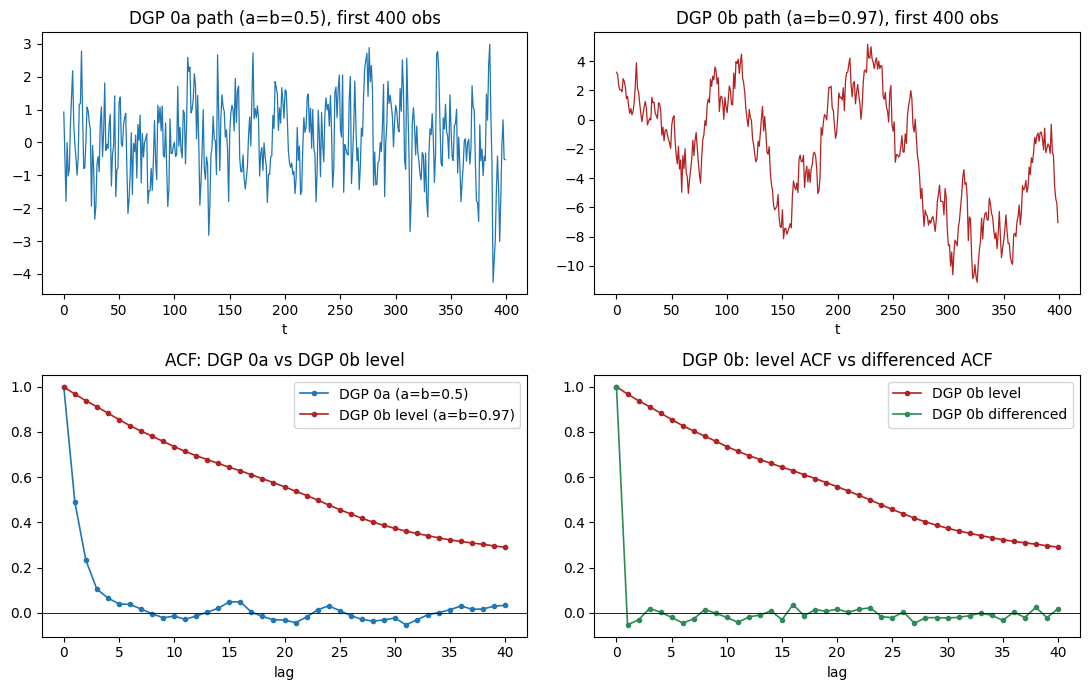

In [8]:
import matplotlib.pyplot as plt

def plot_dgp0_diagnostics(persistence_low: float = 0.5, persistence_high: float = 0.97,
                           n_plot: int = 400, n_full: int = CFG.sample_lengths[0],
                           seed_low: int = CFG.master_seed, seed_high: int = CFG.master_seed + 1) -> None:
    """Four-panel diagnostic plot for DGP 0a/0b: raw paths (moderate vs near-unit-root),
    and ACF comparisons (0a vs 0b level, and 0b level vs 0b differenced).
    ACF panels use line+marker rather than stem, since stem plots hide the smaller-magnitude
    series (a fast-decaying ACF near zero) underneath a slower-decaying series' tall bars."""

    x_low, _ = generate_dgp0(n_full, persistence_low, np.random.default_rng(seed_low))
    x_high, _ = generate_dgp0(n_full, persistence_high, np.random.default_rng(seed_high))
    x_high_diff = difference_series(x_high)

    acf_low = sm_acf(x_low, nlags=40, fft=True)
    acf_high = sm_acf(x_high, nlags=40, fft=True)
    acf_high_diff = sm_acf(x_high_diff, nlags=40, fft=True)

    fig, axes = plt.subplots(2, 2, figsize=(11, 7))

    axes[0, 0].plot(x_low[:n_plot], linewidth=0.9)
    axes[0, 0].set_title(f"DGP 0a path (a=b={persistence_low}), first {n_plot} obs")
    axes[0, 0].set_xlabel("t")

    axes[0, 1].plot(x_high[:n_plot], linewidth=0.9, color="firebrick")
    axes[0, 1].set_title(f"DGP 0b path (a=b={persistence_high}), first {n_plot} obs")
    axes[0, 1].set_xlabel("t")

    axes[1, 0].plot(acf_low, marker="o", markersize=3, linewidth=1.2, label="DGP 0a (a=b=0.5)")
    axes[1, 0].plot(acf_high, marker="o", markersize=3, linewidth=1.2, color="firebrick", label="DGP 0b level (a=b=0.97)")
    axes[1, 0].axhline(0, color="black", linewidth=0.6)
    axes[1, 0].set_title("ACF: DGP 0a vs DGP 0b level")
    axes[1, 0].set_xlabel("lag")
    axes[1, 0].legend()

    axes[1, 1].plot(acf_high, marker="o", markersize=3, linewidth=1.2, color="firebrick", label="DGP 0b level")
    axes[1, 1].plot(acf_high_diff, marker="o", markersize=3, linewidth=1.2, color="seagreen", label="DGP 0b differenced")
    axes[1, 1].axhline(0, color="black", linewidth=0.6)
    axes[1, 1].set_title("DGP 0b: level ACF vs differenced ACF")
    axes[1, 1].set_xlabel("lag")
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


plot_dgp0_diagnostics()

### 2.2 DGP 1 / 1b: Linear Unidirectional

$$X_t = aX_{t-1} + \varepsilon_t, \qquad Y_t = bY_{t-1} + cX_{t-\ell} + \eta_t$$

independent noise, ground truth: X causes Y at lag ℓ, no reverse causality. AR coefficients a=b=0.3 here are deliberately modest, not calibrated to persistence the way DGP 0b was; this DGP is about testing coupling detection, not persistence confounds, so ordinary short-memory dynamics are the right baseline.

- **DGP 1**: ℓ = 1. This is the primary sanity check against Barnett, Barrett and Seth (2009): under Gaussian noise, GC and TE should agree closely here, since their equivalence result holds exactly under Gaussian linear dynamics. Run under Gaussian noise as the main specification, then re-run with the same coefficients under Student-t noise (df=5, per the revised protocol) as the dedicated heavy-tail linear scenario.
- **DGP 1b**: ℓ = 3, otherwise identical. Lag recovery accuracy is a weak test when the true lag is 1, since most causality statistics naturally peak near lag 1 regardless of how precisely a method localises lag. Setting the true lag to 3 (within the primary search range of 1-5) gives a materially stronger test of whether lag recovery accuracy reflects genuine localisation rather than a byproduct of a "lag 1 by default" bias.

Coupling strength c should be chosen so that the true lag's cross-correlation is clearly detectable but not so strong that every method trivially finds it regardless of its actual sensitivity; this is confirmed in the diagnostics below rather than assumed.

In [9]:
def generate_dgp1(n: int, a: float, b: float, c: float, lag: int, rng: np.random.Generator,
                   noise: Literal["gaussian", "student_t"] = "gaussian",
                   df: int = CFG.student_t_df_primary) -> tuple[np.ndarray, np.ndarray]:
    """DGP 1/1b: linear unidirectional, X_t = a*X_{t-1} + eps_t, Y_t = b*Y_{t-1} + c*X_{t-lag} + eta_t.
    lag=1 -> DGP 1 (primary Barnett-Barrett-Seth sanity check); lag=3 -> DGP 1b (lag recovery test).
    """
    total = n + CFG.burn_in + lag  # extra burn-in room so X_{t-lag} is always available post burn-in

    if noise == "gaussian":
        eps = rng.standard_normal(total)
        eta = rng.standard_normal(total)
    elif noise == "student_t":
        eps = student_t_innovation(total, df, rng)
        eta = student_t_innovation(total, df, rng)
    else:
        raise ValueError(f"unknown noise type: {noise}")

    x = np.zeros(total)
    y = np.zeros(total)
    for t in range(1, total):
        x[t] = a * x[t - 1] + eps[t]
        x_lag_term = x[t - lag] if t - lag >= 0 else 0.0
        y[t] = b * y[t - 1] + c * x_lag_term + eta[t]

    start = CFG.burn_in + lag
    return x[start:], y[start:]

### Diagnostics for DGP 1 / 1b

Three checks: (1) both X and Y pass ADF/KPSS as stationary under the standard (non-persistent) calibration, confirming this DGP is not accidentally reintroducing the persistence-confound issue that DGP 0b was built to isolate; (2) the cross-correlation function between X and Y peaks at the true lag ℓ and is comparatively small at other lags, confirming the coupling is actually concentrated where it is meant to be rather than smeared across several lags; (3) the peak cross-correlation magnitude is in a "detectable but not trivial" range, reported numerically so the coupling strength choice is documented rather than assumed.

In [10]:
def cross_correlation_function(x: np.ndarray, y: np.ndarray, max_lag: int) -> dict:
    """corr(X_{t-k}, Y_t) for k = 0..max_lag. Positive k means X leads Y by k periods,
    which is the direction relevant to this DGP's true coupling."""
    ccf = {}
    for k in range(0, max_lag + 1):
        if k == 0:
            ccf[k] = float(np.corrcoef(x, y)[0, 1])
        else:
            ccf[k] = float(np.corrcoef(x[:-k], y[k:])[0, 1])
    return ccf



def diagnose_dgp1(n: int, a: float, b: float, c: float, lag: int, rng: np.random.Generator,
                   label: str, max_lag_scan: int = 8,
                   noise: Literal["gaussian", "student_t"] = "gaussian",
                   df: int = CFG.student_t_df_primary) -> dict:
    """Full diagnostic bundle for one DGP 1/1b configuration: stationarity of X and Y,
    and the CCF peak-location / peak-magnitude check against the true lag."""
    x, y = generate_dgp1(n, a, b, c, lag, rng, noise=noise, df=df)
    ccf = cross_correlation_function(x, y, max_lag_scan)
    peak_lag = max(ccf, key=lambda k: abs(ccf[k]))

    return {
        "label": label,
        "true_lag": lag,
        "x_stationarity": stationarity_report(x, f"{label}_X"),
        "y_stationarity": stationarity_report(y, f"{label}_Y"),
        "ccf": ccf,
        "peak_lag": peak_lag,
        "peak_matches_true_lag": peak_lag == lag,
    }


def print_dgp1_diagnostics(diag: dict) -> None:
    """Readable summary, same pretty-print philosophy as print_dgp0_diagnostics."""
    print(f"=== {diag['label']} (true lag = {diag['true_lag']}) ===")
    print(f"  X stationarity: ADF p={diag['x_stationarity']['adf_p']:.4g}, "
          f"KPSS p={diag['x_stationarity']['kpss_p']:.4g}, "
          f"conflict={diag['x_stationarity']['adf_kpss_conflict']}")
    print(f"  Y stationarity: ADF p={diag['y_stationarity']['adf_p']:.4g}, "
          f"KPSS p={diag['y_stationarity']['kpss_p']:.4g}, "
          f"conflict={diag['y_stationarity']['adf_kpss_conflict']}")
    print(f"  CCF peak at lag {diag['peak_lag']} (true lag {diag['true_lag']}), "
          f"matches={diag['peak_matches_true_lag']}")
    print(f"  CCF by lag: " + ", ".join(f"{k}:{v:.3f}" for k, v in diag['ccf'].items()))
    print()


diag_dgp1 = diagnose_dgp1(CFG.sample_lengths[0], a=0.3, b=0.3, c=0.5, lag=1,
                           rng=np.random.default_rng(CFG.master_seed + 10), label="DGP1")
diag_dgp1b = diagnose_dgp1(CFG.sample_lengths[0], a=0.3, b=0.3, c=0.5, lag=3,
                            rng=np.random.default_rng(CFG.master_seed + 11), label="DGP1b")

print_dgp1_diagnostics(diag_dgp1)
print_dgp1_diagnostics(diag_dgp1b)

=== DGP1 (true lag = 1) ===
  X stationarity: ADF p=0, KPSS p=0.1, conflict=False
  Y stationarity: ADF p=0, KPSS p=0.1, conflict=False
  CCF peak at lag 1 (true lag 1), matches=True
  CCF by lag: 0:0.133, 1:0.475, 2:0.275, 3:0.116, 4:0.017, 5:-0.015, 6:-0.024, 7:-0.004, 8:0.008

=== DGP1b (true lag = 3) ===
  X stationarity: ADF p=0, KPSS p=0.1, conflict=False
  Y stationarity: ADF p=0, KPSS p=0.1, conflict=False
  CCF peak at lag 3 (true lag 3), matches=True
  CCF by lag: 0:0.050, 1:0.063, 2:0.174, 3:0.502, 4:0.258, 5:0.128, 6:0.082, 7:0.026, 8:0.016



/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84

### CCF visualisation for DGP 1 / 1b

A single figure with the CCF profiles for both DGP 1 and DGP 1b side by side, each with a vertical marker at the true lag. This is the direct synthetic counterpart to the CCF plots in the real-data EDA (Section 7), useful both as a quick visual confirmation that the coupling is concentrated where intended and as a candidate figure for the dissertation, since a reader can compare this synthetic CCF profile against the real-data one to judge whether the synthetic DGP is a reasonable stand-in. A raw time-series path plot is not included here, unlike DGP 0a/0b: at a=b=0.3 the AR dynamics are mild enough that the lag-1 versus lag-3 distinction would not be visible in the path itself, it only shows up in the CCF, so a path plot would add no diagnostic value in this case.

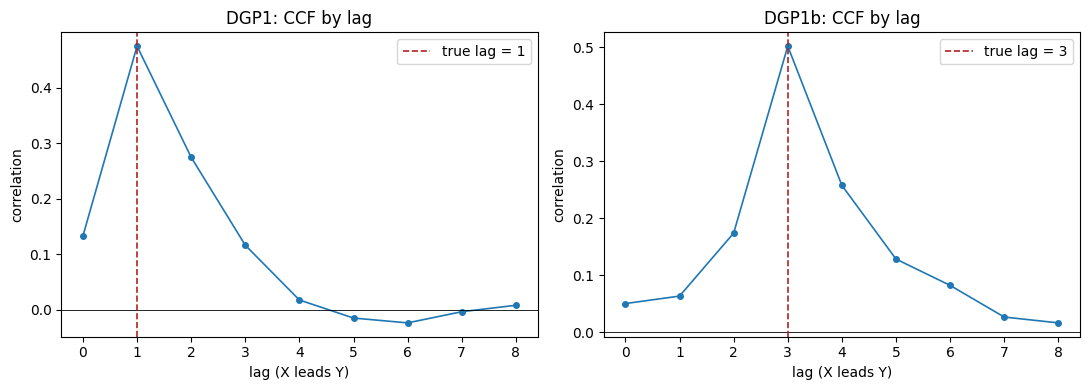

In [11]:
def plot_dgp1_ccf(diag1: dict, diag1b: dict, max_lag_scan: int = 8) -> None:
    """CCF-by-lag comparison for DGP 1 (true lag 1) and DGP 1b (true lag 3), each with a
    vertical marker at its true lag, mirroring the CCF plots used in the real-data EDA."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    for ax, diag in zip(axes, [diag1, diag1b]):
        lags = list(diag["ccf"].keys())
        vals = list(diag["ccf"].values())
        ax.plot(lags, vals, marker="o", markersize=4, linewidth=1.2)
        ax.axhline(0, color="black", linewidth=0.6)
        ax.axvline(diag["true_lag"], color="firebrick", linestyle="--", linewidth=1.2,
                   label=f"true lag = {diag['true_lag']}")
        ax.set_title(f"{diag['label']}: CCF by lag")
        ax.set_xlabel("lag (X leads Y)")
        ax.set_ylabel("correlation")
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_dgp1_ccf(diag_dgp1, diag_dgp1b)

### DGP 1: Student-t heavy-tail variant

Same coefficients as DGP 1 (a=b=0.3, c=0.5, true lag=1), the only change is the innovation distribution: standardised Student-t with df=5, matching the excess kurtosis actually estimated for the real FX and rate series in the EDA, rather than df≤4 which would leave the fourth moment undefined.

This is the dedicated heavy-tail linear scenario discussed in the design document: because the coupling structure is identical to the Gaussian DGP 1, any difference in GC's or TE's detection performance here can be attributed specifically to the change in innovation distribution, not to a confound between "nonlinear" and "heavy-tailed." Diagnostics repeat the same three checks as the Gaussian version (stationarity, CCF peak location, peak magnitude), so the two versions can be compared directly on identical grounds.

In [12]:
diag_dgp1_t = diagnose_dgp1(CFG.sample_lengths[0], a=0.3, b=0.3, c=0.5, lag=1,
                             rng=np.random.default_rng(CFG.master_seed + 12), label="DGP1_studentt",
                             noise="student_t", df=CFG.student_t_df_primary)

print_dgp1_diagnostics(diag_dgp1_t)

print(f"Peak CCF magnitude, Gaussian vs Student-t (df={CFG.student_t_df_primary}): "
      f"{diag_dgp1['ccf'][diag_dgp1['peak_lag']]:.3f} vs {diag_dgp1_t['ccf'][diag_dgp1_t['peak_lag']]:.3f}")

=== DGP1_studentt (true lag = 1) ===
  X stationarity: ADF p=0, KPSS p=0.1, conflict=False
  Y stationarity: ADF p=0, KPSS p=0.1, conflict=False
  CCF peak at lag 1 (true lag 1), matches=True
  CCF by lag: 0:0.134, 1:0.481, 2:0.288, 3:0.107, 4:0.045, 5:0.015, 6:-0.007, 7:-0.009, 8:-0.026

Peak CCF magnitude, Gaussian vs Student-t (df=5): 0.475 vs 0.481


/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")


### 2.3 DGP 2 / 2b: Nonlinear Unidirectional

$$X_t = aX_{t-1} + \varepsilon_t, \qquad Y_t = bY_{t-1} + c\left(X_{t-\ell}^2 - E[X^2]\right) + \eta_t$$

independent noise, ground truth: X causes Y nonlinearly at lag ℓ, no reverse causality, and critically, **no linear** dependence at the true lag by construction, since $X_{t-\ell}^2 - E[X^2]$ is uncorrelated with $X_{t-\ell}$ itself under symmetric innovations. This is the core novelty-validation scenario: linear GC's coupling detection here relies entirely on whatever linear correlation happens to leak through the AR(1) autocorrelation structure of X, not on the coupling term itself, so GC's power is expected to be visibly weaker than in DGP 1, while TE, which does not assume a linear functional form, is expected to detect the true direction reliably.

- **DGP 2**: ℓ = 1, Gaussian noise, a=b=0.3 (same AR structure as DGP 1, so any detection differences trace to the squared coupling, not to different AR dynamics).
- **DGP 2b**: ℓ = 3, otherwise identical, the nonlinear counterpart to DGP 1b's lag-recovery test, applied here specifically because this is the scenario the novelty claim rests on most heavily.
- **DGP 2, Student-t variant**: same coefficients as DGP 2, innovations at df=5. Squared coupling amplifies tail behaviour more than linear coupling does, since $X^2$ inherits whatever heavy-tailedness X has and compounds it, so this is the case where heavy tails are most likely to interact with the nonlinearity, and the case most directly relevant to your EDA finding of pronounced excess kurtosis in the rate and commodity series.

Threshold and tanh coupling are noted here as optional secondary specifications within this DGP family (replacing the squared term with $c \cdot \mathbb{1}[X_{t-\ell} > \tau]$ or $c \cdot \tanh(X_{t-\ell})$) but are not built by default; they can be added later without renumbering if time allows.

In [13]:
def generate_dgp2(n: int, a: float, b: float, c: float, lag: int, rng: np.random.Generator,
                   noise: Literal["gaussian", "student_t"] = "gaussian",
                   df: int = CFG.student_t_df_primary) -> tuple[np.ndarray, np.ndarray]:
    """DGP 2/2b: nonlinear unidirectional via squared coupling,
    X_t = a*X_{t-1} + eps_t, Y_t = b*Y_{t-1} + c*(X_{t-lag}^2 - E[X^2]) + eta_t.
    E[X^2] is estimated from the generated X series itself (post burn-in), not assumed
    analytically, since the AR(1) stationary variance depends on the noise distribution.
    lag=1 -> DGP 2; lag=3 -> DGP 2b.
    """
    total = n + CFG.burn_in + lag

    if noise == "gaussian":
        eps = rng.standard_normal(total)
        eta = rng.standard_normal(total)
    elif noise == "student_t":
        eps = student_t_innovation(total, df, rng)
        eta = student_t_innovation(total, df, rng)
    else:
        raise ValueError(f"unknown noise type: {noise}")

    x = np.zeros(total)
    for t in range(1, total):
        x[t] = a * x[t - 1] + eps[t]

    # E[X^2] estimated post burn-in, so the centring constant reflects the actual stationary
    # distribution of X under this noise type rather than a Gaussian-only analytic formula
    x_post_burnin = x[CFG.burn_in:]
    ex2 = float(np.mean(x_post_burnin ** 2))

    y = np.zeros(total)
    for t in range(1, total):
        x_lag_sq = (x[t - lag] ** 2 - ex2) if t - lag >= 0 else 0.0
        y[t] = b * y[t - 1] + c * x_lag_sq + eta[t]

    start = CFG.burn_in + lag
    return x[start:], y[start:]

### Diagnostics for DGP 2 / 2b

Four checks here, one more than the linear DGPs: (1) stationarity of X and Y; (2) confirmation that $X_{t-\ell}$ and $X_{t-\ell}^2$ are indeed close to linearly uncorrelated in the generated sample, verifying the "no linear channel" property the DGP relies on, since finite-sample noise could in principle introduce a small spurious linear correlation even under a symmetric distribution; (3) the CCF between X and Y at the true lag should be comparatively weak given (2), this is expected and is not a design flaw, it is the reason linear GC's power is expected to be low here; (4) a nonlinear dependence check, using a simple squared-CCF style diagnostic ($corr(X_{t-\ell}^2, Y_t)$) as a quick model-free confirmation that the coupling is detectable in the second-moment relationship even though it is close to invisible in the raw CCF.

In [14]:
def diagnose_dgp2(n: int, a: float, b: float, c: float, lag: int, rng: np.random.Generator,
                   label: str, max_lag_scan: int = 8,
                   noise: Literal["gaussian", "student_t"] = "gaussian",
                   df: int = CFG.student_t_df_primary) -> dict:
    """Full diagnostic bundle for one DGP 2/2b configuration: stationarity, the "no linear
    channel" check (corr(X_{t-lag}, X_{t-lag}^2)), the (expected to be weak) linear CCF,
    and a squared-CCF check confirming the nonlinear coupling is present and detectable."""
    x, y = generate_dgp2(n, a, b, c, lag, rng, noise=noise, df=df)

    # (1) stationarity
    x_stat = stationarity_report(x, f"{label}_X")
    y_stat = stationarity_report(y, f"{label}_Y")

    # (2) "no linear channel" check: corr(X_{t-lag}, X_{t-lag}^2) should be close to 0
    if lag == 0:
        x_lagged, x_lagged_sq = x, x ** 2
    else:
        x_lagged = x[:-lag]
        x_lagged_sq = (x ** 2)[:-lag]
    linear_channel_corr = float(np.corrcoef(x_lagged, x_lagged_sq)[0, 1])

    # (3) standard linear CCF between X and Y, expected to be weak at the true lag
    ccf = cross_correlation_function(x, y, max_lag_scan)
    peak_lag_linear = max(ccf, key=lambda k: abs(ccf[k]))

    # (4) squared-CCF: corr(X_{t-k}^2, Y_t) across lags, expects a clear peak at true lag
    x_sq = x ** 2
    squared_ccf = {}
    for k in range(0, max_lag_scan + 1):
        if k == 0:
            squared_ccf[k] = float(np.corrcoef(x_sq, y)[0, 1])
        else:
            squared_ccf[k] = float(np.corrcoef(x_sq[:-k], y[k:])[0, 1])
    peak_lag_squared = max(squared_ccf, key=lambda k: abs(squared_ccf[k]))

    return {
        "label": label,
        "true_lag": lag,
        "x_stationarity": x_stat,
        "y_stationarity": y_stat,
        "linear_channel_corr": linear_channel_corr,
        "ccf_linear": ccf,
        "peak_lag_linear": peak_lag_linear,
        "ccf_squared": squared_ccf,
        "peak_lag_squared": peak_lag_squared,
        "squared_peak_matches_true_lag": peak_lag_squared == lag,
    }


def print_dgp2_diagnostics(diag: dict) -> None:
    """Readable summary for DGP 2/2b, structured to make the linear-vs-nonlinear contrast
    the central point rather than burying it among the four sub-checks."""
    print(f"=== {diag['label']} (true lag = {diag['true_lag']}) ===")
    print(f"  X stationarity: ADF p={diag['x_stationarity']['adf_p']:.4g}, "
          f"KPSS p={diag['x_stationarity']['kpss_p']:.4g}, "
          f"conflict={diag['x_stationarity']['adf_kpss_conflict']}")
    print(f"  Y stationarity: ADF p={diag['y_stationarity']['adf_p']:.4g}, "
          f"KPSS p={diag['y_stationarity']['kpss_p']:.4g}, "
          f"conflict={diag['y_stationarity']['adf_kpss_conflict']}")
    print(f"  corr(X_lag, X_lag^2) [should be ~0]: {diag['linear_channel_corr']:.4f}")
    print(f"  Linear CCF peak at lag {diag['peak_lag_linear']} "
          f"(value {diag['ccf_linear'][diag['peak_lag_linear']]:.3f}) -- expected to be weak")
    print(f"  Squared CCF peak at lag {diag['peak_lag_squared']} (true lag {diag['true_lag']}), "
          f"matches={diag['squared_peak_matches_true_lag']} "
          f"(value {diag['ccf_squared'][diag['peak_lag_squared']]:.3f})")
    print()


diag_dgp2 = diagnose_dgp2(CFG.sample_lengths[0], a=0.3, b=0.3, c=0.5, lag=1,
                           rng=np.random.default_rng(CFG.master_seed + 20), label="DGP2")
diag_dgp2b = diagnose_dgp2(CFG.sample_lengths[0], a=0.3, b=0.3, c=0.5, lag=3,
                            rng=np.random.default_rng(CFG.master_seed + 21), label="DGP2b")

print_dgp2_diagnostics(diag_dgp2)
print_dgp2_diagnostics(diag_dgp2b)

/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")


=== DGP2 (true lag = 1) ===
  X stationarity: ADF p=0, KPSS p=0.1, conflict=False
  Y stationarity: ADF p=0, KPSS p=0.1, conflict=False
  corr(X_lag, X_lag^2) [should be ~0]: 0.0951
  Linear CCF peak at lag 3 (value 0.071) -- expected to be weak
  Squared CCF peak at lag 1 (true lag 1), matches=True (value 0.606)

=== DGP2b (true lag = 3) ===
  X stationarity: ADF p=0, KPSS p=0.1, conflict=False
  Y stationarity: ADF p=0, KPSS p=0.1, conflict=False
  corr(X_lag, X_lag^2) [should be ~0]: -0.0109
  Linear CCF peak at lag 7 (value 0.023) -- expected to be weak
  Squared CCF peak at lag 3 (true lag 3), matches=True (value 0.619)



/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")



First, `corr(X_lag, X_lag^2)` is small (0.095 for DGP 2, -0.011 for DGP 2b) but not exactly zero, as expected under finite-sample noise even though the population value is exactly zero for a symmetric distribution. At n=2500, a correlation of 0.095 is technically statistically significant, so this is best described as a genuine but very weak residual linear channel, not as "no linear leakage at all." This is small enough that it cannot plausibly account for the much larger squared-CCF values below, but it should be reported as such rather than rounded down to "confirmed zero."

Second, and more importantly, the linear CCF peaks (DGP 2: lag 3, value 0.071; DGP 2b: lag 7, value 0.023) do **not** land on the true lag in either case, and the values themselves are small. This is the expected behaviour, not a failure: since the coupling has no linear component by construction, the linear CCF has no reason to peak at the true lag specifically, what is observed here is noise-level fluctuation across lags with no genuine structure. This is itself the diagnostic evidence that linear GC's power on this DGP will depend entirely on incidental leakage rather than on detecting the actual coupling.

The squared CCF, by contrast, peaks exactly at the true lag in both cases (DGP 2: lag 1, value 0.606; DGP 2b: lag 3, value 0.619), at comparable magnitude across the two lag settings, confirming both that the nonlinear coupling is genuinely present and detectable, and that its strength was not accidentally altered when the true lag was changed from 1 to 3.

### DGP 2: Student-t heavy-tail variant

Same coefficients as DGP 2 (a=b=0.3, c=0.5, true lag=1), innovations switched to standardised Student-t with df=5. As noted earlier, squared coupling is the specification most likely to interact with heavy tails, since $X^2$ compounds whatever tail heaviness X already has, so this comparison is watched more closely than the DGP 1 Student-t check was.

Expected outcome, per the design document's stated expectations: GC and TE should still broadly identify the correct direction, GC's power may show more finite-sample sensitivity to the extreme values than it did under Gaussian noise, and TE should not become spuriously more significant simply because the data is non-Gaussian. This diagnostic stage only checks the squared-CCF descriptive statistic; the actual GC/TE comparison happens once the methods are implemented in Section 3.

In [15]:
diag_dgp2_t = diagnose_dgp2(CFG.sample_lengths[0], a=0.3, b=0.3, c=0.5, lag=1,
                             rng=np.random.default_rng(CFG.master_seed + 22), label="DGP2_studentt",
                             noise="student_t", df=CFG.student_t_df_primary)

print_dgp2_diagnostics(diag_dgp2_t)

print(f"Squared CCF peak magnitude, Gaussian vs Student-t (df={CFG.student_t_df_primary}): "
      f"{diag_dgp2['ccf_squared'][diag_dgp2['peak_lag_squared']]:.3f} vs "
      f"{diag_dgp2_t['ccf_squared'][diag_dgp2_t['peak_lag_squared']]:.3f}")
print(f"corr(X_lag, X_lag^2), Gaussian vs Student-t: "
      f"{diag_dgp2['linear_channel_corr']:.4f} vs {diag_dgp2_t['linear_channel_corr']:.4f}")

/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")


=== DGP2_studentt (true lag = 1) ===
  X stationarity: ADF p=0, KPSS p=0.1, conflict=False
  Y stationarity: ADF p=0, KPSS p=0.1, conflict=False
  corr(X_lag, X_lag^2) [should be ~0]: 0.1868
  Linear CCF peak at lag 1 (value 0.171) -- expected to be weak
  Squared CCF peak at lag 1 (true lag 1), matches=True (value 0.786)

Squared CCF peak magnitude, Gaussian vs Student-t (df=5): 0.606 vs 0.786
corr(X_lag, X_lag^2), Gaussian vs Student-t: 0.0951 vs 0.1868


/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")


### Reading the DGP 2 Student-t diagnostics

The concern flagged in the DGP 2 Student-t description is confirmed here: `corr(X_lag, X_lag^2)` rises from 0.095 under Gaussian noise to 0.187 under Student-t (df=5), essentially doubling. This is a known consequence of heavy-tailed innovations, higher-order moments grow substantially even though the population-level symmetry argument (zero third moment) still holds exactly, so a small number of extreme joint observations can dominate the finite-sample covariance between X and X². The squared-CCF peak also rises, from 0.606 to 0.786, and notably the linear CCF peak rises too, from 0.071 to 0.171 (coincidentally still located at lag 1, the true lag, though this coincidence should not be read as linear GC "working" here).

The implication carried forward to Section 3 is that this DGP's "no linear channel" property is noticeably less clean under heavy tails than under Gaussian noise. This does not invalidate the scenario, both the residual linear correlation and the squared coupling remain much smaller and much larger respectively than what would indicate a design error, but it does mean that if linear GC shows any detectable power on the DGP 2 Student-t variant in Section 3, this diagnostic result is the reason to check first, before concluding GC has somehow learned to detect nonlinear structure: it may simply be picking up the amplified residual linear leakage documented here, not the coupling itself.

### Linear vs squared CCF visualisation, DGP 2 / 2b

Two panels, one per DGP configuration, each overlaying the linear CCF and the squared CCF across the same lag range, with a vertical marker at the true lag. This is the single most important figure in the Tier 1 DGP suite for the novelty argument: it makes visible, in one image, the fact that the linear relationship is flat and uninformative across all lags while the squared relationship shows a clear, correctly-located peak. This is the synthetic analogue of the argument that linear GC and TE should diverge specifically where nonlinear dependence exists (Barnett, Barrett and Seth, 2009), shown here at the descriptive-statistic level before the actual causality tests are run in Section 3.

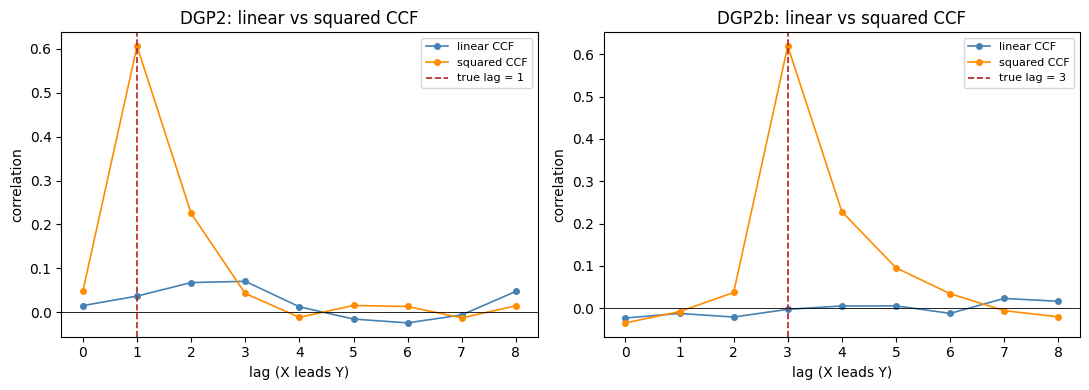

In [55]:
def plot_dgp2_ccf_comparison(diag2: dict, diag2b: dict) -> None:
    """Linear CCF vs squared CCF, side by side for DGP 2 and DGP 2b, each with the true lag
    marked. The central visual argument: linear CCF is flat/uninformative, squared CCF peaks
    exactly at the true lag."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    for ax, diag in zip(axes, [diag2, diag2b]):
        lags = list(diag["ccf_linear"].keys())
        lin_vals = list(diag["ccf_linear"].values())
        sq_vals = list(diag["ccf_squared"].values())

        ax.plot(lags, lin_vals, marker="o", markersize=4, linewidth=1.2,
                color="steelblue", label="linear CCF")
        ax.plot(lags, sq_vals, marker="o", markersize=4, linewidth=1.2,
                color="darkorange", label="squared CCF")
        ax.axhline(0, color="black", linewidth=0.6)
        ax.axvline(diag["true_lag"], color="firebrick", linestyle="--", linewidth=1.2,
                   label=f"true lag = {diag['true_lag']}")
        ax.set_title(f"{diag['label']}: linear vs squared CCF")
        ax.set_xlabel("lag (X leads Y)")
        ax.set_ylabel("correlation")
        ax.legend(fontsize=8)


    plt.tight_layout()

    fig.savefig(
        "figure_5_1_dgp2_ccf_comparison.pdf",
        bbox_inches="tight"
    )

plt.show()

plot_dgp2_ccf_comparison(diag_dgp2, diag_dgp2b)

### 2.4 DGP 3: Bidirectional Transmission

$$X_t = aX_{t-1} + dY_{t-1} + \varepsilon_t, \qquad Y_t = bY_{t-1} + cX_{t-1} + \eta_t$$

independent noise, ground truth: causality in both directions, at lag 1 in each direction. Unlike DGP 1/2's unidirectional design, the specific question here is not "can the method detect a direction" but "does the method report the two directions symmetrically when the true coupling is symmetric."

Coefficients are set with **c = d**, deliberately equal, so that any asymmetry a method reports between the X→Y and Y→X directions cannot be attributed to a genuine asymmetry in the DGP itself, it must instead reflect an estimator artefact (e.g. one direction's regression having systematically more residual variance to work with, or a KSG implementation detail that behaves asymmetrically even under symmetric inputs). This is the reason DGP 3 exists as a separate check rather than being folded into DGP 1: DGP 1 tests direction detection when the true relationship is asymmetric, DGP 3 tests direction-reporting fidelity when the true relationship is exactly symmetric.

AR coefficients a=b=0.3, coupling c=d=0.4, matching the same "modest AR, moderate coupling" philosophy as DGP 1/2 rather than DGP 0b's persistence calibration, since persistence is not what this DGP is testing.

In [17]:
def generate_dgp3(n: int, a: float, b: float, c: float, d: float, rng: np.random.Generator,
                   noise: Literal["gaussian", "student_t"] = "gaussian",
                   df: int = CFG.student_t_df_primary) -> tuple[np.ndarray, np.ndarray]:
    """DGP 3: bidirectional transmission at lag 1 in both directions.
    X_t = a*X_{t-1} + d*Y_{t-1} + eps_t, Y_t = b*Y_{t-1} + c*X_{t-1} + eta_t.
    c=d by default in the calling convention below, to keep the true coupling symmetric.
    """
    total = n + CFG.burn_in

    if noise == "gaussian":
        eps = rng.standard_normal(total)
        eta = rng.standard_normal(total)
    elif noise == "student_t":
        eps = student_t_innovation(total, df, rng)
        eta = student_t_innovation(total, df, rng)
    else:
        raise ValueError(f"unknown noise type: {noise}")

    x = np.zeros(total)
    y = np.zeros(total)
    for t in range(1, total):
        x[t] = a * x[t - 1] + d * y[t - 1] + eps[t]
        y[t] = b * y[t - 1] + c * x[t - 1] + eta[t]

    return x[CFG.burn_in:], y[CFG.burn_in:]

### Diagnostics for DGP 3

Three checks: (1) stationarity of both X and Y; (2) CCF in both directions (corr(X_{t-1}, Y_t) and corr(Y_{t-1}, X_t)), which should both show a comparable peak at lag 1 given c=d, this is the numeric confirmation that the symmetry built into the DGP is actually realised in the generated sample, not just assumed from the equations; (3) a direct comparison of the two peak magnitudes, reported as a ratio or a difference, since this specific number becomes the benchmark against which any asymmetry reported later by GC/TE in Section 3 is judged, if the DGP-level asymmetry here is small, a much larger asymmetry showing up in the method results later is attributable to the method, not to residual DGP-level imbalance.

In [18]:
def diagnose_dgp3(n: int, a: float, b: float, c: float, d: float, rng: np.random.Generator,
                   label: str) -> dict:
    """Diagnostic bundle for DGP 3: stationarity, CCF in both directions, and the
    peak-magnitude symmetry check that later Section 3 asymmetry findings are judged against."""
    x, y = generate_dgp3(n, a, b, c, d, rng)

    x_stat = stationarity_report(x, f"{label}_X")
    y_stat = stationarity_report(y, f"{label}_Y")

    # X leads Y direction: corr(X_{t-1}, Y_t)
    ccf_x_to_y = float(np.corrcoef(x[:-1], y[1:])[0, 1])
    # Y leads X direction: corr(Y_{t-1}, X_t)
    ccf_y_to_x = float(np.corrcoef(y[:-1], x[1:])[0, 1])

    asymmetry = abs(ccf_x_to_y - ccf_y_to_x)

    return {
        "label": label,
        "x_stationarity": x_stat,
        "y_stationarity": y_stat,
        "ccf_x_to_y_lag1": ccf_x_to_y,
        "ccf_y_to_x_lag1": ccf_y_to_x,
        "dgp_level_asymmetry": asymmetry,
    }


def print_dgp3_diagnostics(diag: dict) -> None:
    print(f"=== {diag['label']} ===")
    print(f"  X stationarity: ADF p={diag['x_stationarity']['adf_p']:.4g}, "
          f"KPSS p={diag['x_stationarity']['kpss_p']:.4g}, "
          f"conflict={diag['x_stationarity']['adf_kpss_conflict']}")
    print(f"  Y stationarity: ADF p={diag['y_stationarity']['adf_p']:.4g}, "
          f"KPSS p={diag['y_stationarity']['kpss_p']:.4g}, "
          f"conflict={diag['y_stationarity']['adf_kpss_conflict']}")
    print(f"  CCF X->Y (lag 1): {diag['ccf_x_to_y_lag1']:.4f}")
    print(f"  CCF Y->X (lag 1): {diag['ccf_y_to_x_lag1']:.4f}")
    print(f"  DGP-level asymmetry (|difference|): {diag['dgp_level_asymmetry']:.4f}  "
          f"<- reference baseline for judging Section 3 method asymmetry")
    print()


diag_dgp3 = diagnose_dgp3(CFG.sample_lengths[0], a=0.3, b=0.3, c=0.4, d=0.4,
                           rng=np.random.default_rng(CFG.master_seed + 30), label="DGP3")

print_dgp3_diagnostics(diag_dgp3)

=== DGP3 ===
  X stationarity: ADF p=0, KPSS p=0.1, conflict=False
  Y stationarity: ADF p=0, KPSS p=0.08948, conflict=False
  CCF X->Y (lag 1): 0.5096
  CCF Y->X (lag 1): 0.4953
  DGP-level asymmetry (|difference|): 0.0143  <- reference baseline for judging Section 3 method asymmetry



/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")


### Full-lag CCF scan for DGP 3

The diagnostics above only evaluated lag 1 in each direction, since that is the DGP's true lag. For visualisation, and as an extra check that no unintended coupling leaks into other lags, both directions' CCF are scanned across lags 0-8 here, reusing `cross_correlation_function` from Section 2.2. The expectation is two profiles that both peak at lag 1, at comparable magnitude, with no other lag showing a comparably sized peak in either direction.

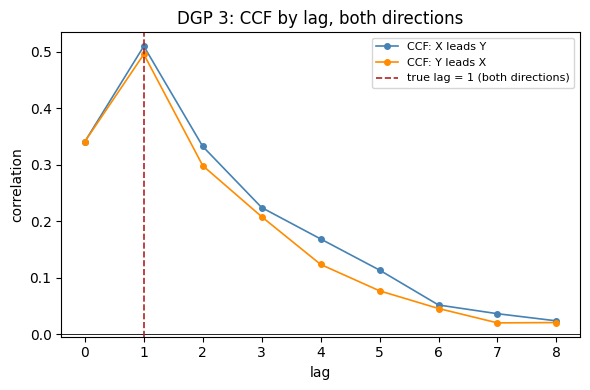

In [19]:
def scan_dgp3_ccf(x: np.ndarray, y: np.ndarray, max_lag: int = 8) -> tuple[dict, dict]:
    """Full CCF-by-lag scan in both directions for DGP 3, reusing the Section 2.2 utility."""
    ccf_x_to_y = cross_correlation_function(x, y, max_lag)   # X_{t-k} vs Y_t
    ccf_y_to_x = cross_correlation_function(y, x, max_lag)   # Y_{t-k} vs X_t
    return ccf_x_to_y, ccf_y_to_x


def plot_dgp3_ccf(ccf_x_to_y: dict, ccf_y_to_x: dict) -> None:
    """Both directions' CCF overlaid, with a marker at lag 1 (the true lag for both directions).
    Expected: near-symmetric peaks at lag 1, both profiles otherwise flat."""
    fig, ax = plt.subplots(figsize=(6, 4))

    lags = list(ccf_x_to_y.keys())
    ax.plot(lags, list(ccf_x_to_y.values()), marker="o", markersize=4, linewidth=1.2,
            color="steelblue", label="CCF: X leads Y")
    ax.plot(lags, list(ccf_y_to_x.values()), marker="o", markersize=4, linewidth=1.2,
            color="darkorange", label="CCF: Y leads X")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.axvline(1, color="firebrick", linestyle="--", linewidth=1.2, label="true lag = 1 (both directions)")
    ax.set_title("DGP 3: CCF by lag, both directions")
    ax.set_xlabel("lag")
    ax.set_ylabel("correlation")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


x_dgp3, y_dgp3 = generate_dgp3(CFG.sample_lengths[0], a=0.3, b=0.3, c=0.4, d=0.4,
                                 rng=np.random.default_rng(CFG.master_seed + 30))
ccf_x_to_y_full, ccf_y_to_x_full = scan_dgp3_ccf(x_dgp3, y_dgp3)
plot_dgp3_ccf(ccf_x_to_y_full, ccf_y_to_x_full)

### 2.5 DGP 4a / 4b: Common Driver

$$Z_t = \rho Z_{t-1} + \nu_t$$

Both X and Y are driven by the same latent Z, with no direct link between X and Y. Ground truth: no direct causality either direction, in both versions. The two versions differ only in the timing of exposure to Z.

- **DGP 4a, same-lag common driver**:
$$X_t = a X_{t-1} + \phi_X Z_{t-1} + \varepsilon_t, \qquad Y_t = b Y_{t-1} + \phi_Y Z_{t-1} + \eta_t$$
X and Y respond to the same lag of Z. Since neither leads the other in time, this version is expected to mainly generate contemporaneous correlation between X and Y rather than any directional pattern, and serves as the reference case: pairwise methods should not assign a direction here.

- **DGP 4b, staggered common driver**:
$$X_t = a X_{t-1} + \phi_X Z_{t-1} + \varepsilon_t, \qquad Y_t = b Y_{t-1} + \phi_Y Z_{t-2} + \eta_t$$
X is exposed to Z one period earlier than Y. Ground truth is still no direct causality, but because X's response to the shared shock precedes Y's in time, pairwise GC or TE applied to (X, Y) alone may spuriously report X→Y. This is the more realistic version of the common-driver concern, corresponding to markets reacting at different speeds to the same macro shock being misread as genuine cross-market spillover. DGP 4b is followed by a conditioning check: the same test re-run controlling for Z (a partial/trivariate version), which should show the spurious direction disappear once Z is accounted for.

ρ=0.5 for Z's own persistence (moderate, not calibrated to DGP 0b's near-unit-root level, since persistence confounds are DGP 0b/0's concern, not this DGP's), a=b=0.3 for X and Y's own AR dynamics (same as DGP 1/2/3), φ_X=φ_Y=0.5 for the loading on Z (equal loadings, so any asymmetry that shows up is attributable to the staggered timing alone, not to one series depending on Z more strongly than the other).

In [20]:
def generate_dgp4(n: int, a: float, b: float, phi_x: float, phi_y: float, rho: float,
                   rng: np.random.Generator, staggered: bool,
                   noise: Literal["gaussian", "student_t"] = "gaussian",
                   df: int = CFG.student_t_df_primary) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """DGP 4a/4b: common driver. Returns Z pre-aligned so that z_extended[i] corresponds to
    Z_{t-2} at the same time index i as x[i], y[i] -- this enables exact extraction of the
    Z lag shared by X and Y for the DGP 4b conditioning check, without further index arithmetic
    downstream."""
    extra = 2 if staggered else 1
    total = n + CFG.burn_in + extra

    if noise == "gaussian":
        eps = rng.standard_normal(total)
        eta = rng.standard_normal(total)
        nu = rng.standard_normal(total)
    elif noise == "student_t":
        eps = student_t_innovation(total, df, rng)
        eta = student_t_innovation(total, df, rng)
        nu = student_t_innovation(total, df, rng)
    else:
        raise ValueError(f"unknown noise type: {noise}")

    z = np.zeros(total)
    for t in range(1, total):
        z[t] = rho * z[t - 1] + nu[t]

    x = np.zeros(total)
    y = np.zeros(total)
    for t in range(1, total):
        z_lag_x = z[t - 1] if t - 1 >= 0 else 0.0
        x[t] = a * x[t - 1] + phi_x * z_lag_x + eps[t]

        y_z_lag = 2 if staggered else 1
        z_lag_y = z[t - y_z_lag] if t - y_z_lag >= 0 else 0.0
        y[t] = b * y[t - 1] + phi_y * z_lag_y + eta[t]

    start = CFG.burn_in + extra
    # z_extended[i] = Z_{(start+i)-2}, i.e. exactly aligned index-for-index with x[i], y[i];
    # trimmed to length n to match x[start:], y[start:] -- this trim was missing before.
    return x[start:], y[start:], z[start - 2: total - 2]


### Diagnostics for DGP 4a: same-lag common driver

Two checks: (1) stationarity of X, Y, Z; (2) the CCF between X and Y across lags, both directions. The expectation stated in the design is that this version mainly generates contemporaneous correlation, since X and Y respond to the same lag of Z. Concretely: the lag-0 (contemporaneous) correlation should be the largest value in both directions' CCF profiles, and no single non-zero lag should show a peak that looks like a genuine directional signal in either direction. If a directional pattern were to appear here, that would indicate a coding error in the DGP rather than a genuine finding, since the equations were built specifically so that neither series leads the other.

In [21]:
def diagnose_dgp4a(n: int, a: float, b: float, phi_x: float, phi_y: float, rho: float,
                    rng: np.random.Generator, label: str, max_lag_scan: int = 8) -> dict:
    """Diagnostics for DGP 4a: stationarity of X/Y/Z, and CCF in both directions, expecting
    the lag-0 (contemporaneous) value to dominate with no genuine directional peak."""
    x, y, z = generate_dgp4(n, a, b, phi_x, phi_y, rho, rng, staggered=False)

    x_stat = stationarity_report(x, f"{label}_X")
    y_stat = stationarity_report(y, f"{label}_Y")
    z_stat = stationarity_report(z, f"{label}_Z")

    ccf_x_to_y = cross_correlation_function(x, y, max_lag_scan)
    ccf_y_to_x = cross_correlation_function(y, x, max_lag_scan)

    peak_lag_x_to_y = max(ccf_x_to_y, key=lambda k: abs(ccf_x_to_y[k]))
    peak_lag_y_to_x = max(ccf_y_to_x, key=lambda k: abs(ccf_y_to_x[k]))

    return {
        "label": label,
        "x_stationarity": x_stat,
        "y_stationarity": y_stat,
        "z_stationarity": z_stat,
        "ccf_x_to_y": ccf_x_to_y,
        "ccf_y_to_x": ccf_y_to_x,
        "peak_lag_x_to_y": peak_lag_x_to_y,
        "peak_lag_y_to_x": peak_lag_y_to_x,
        "contemporaneous_dominates": (
            abs(ccf_x_to_y[0]) == max(abs(v) for v in ccf_x_to_y.values()) and
            abs(ccf_y_to_x[0]) == max(abs(v) for v in ccf_y_to_x.values())
        ),
    }


def print_dgp4a_diagnostics(diag: dict) -> None:
    print(f"=== {diag['label']} ===")
    for series in ["x", "y", "z"]:
        s = diag[f"{series}_stationarity"]
        print(f"  {series.upper()} stationarity: ADF p={s['adf_p']:.4g}, KPSS p={s['kpss_p']:.4g}, "
              f"conflict={s['adf_kpss_conflict']}")
    print(f"  CCF X->Y: lag0={diag['ccf_x_to_y'][0]:.3f}, peak at lag {diag['peak_lag_x_to_y']} "
          f"(value {diag['ccf_x_to_y'][diag['peak_lag_x_to_y']]:.3f})")
    print(f"  CCF Y->X: lag0={diag['ccf_y_to_x'][0]:.3f}, peak at lag {diag['peak_lag_y_to_x']} "
          f"(value {diag['ccf_y_to_x'][diag['peak_lag_y_to_x']]:.3f})")
    print(f"  Contemporaneous (lag 0) dominates both directions: {diag['contemporaneous_dominates']}")
    print()


diag_dgp4a = diagnose_dgp4a(CFG.sample_lengths[0], a=0.3, b=0.3, phi_x=0.5, phi_y=0.5, rho=0.5,
                             rng=np.random.default_rng(CFG.master_seed + 40), label="DGP4a")

print_dgp4a_diagnostics(diag_dgp4a)

=== DGP4a ===
  X stationarity: ADF p=6.033e-28, KPSS p=0.1, conflict=False
  Y stationarity: ADF p=0, KPSS p=0.1, conflict=False
  Z stationarity: ADF p=0, KPSS p=0.1, conflict=False
  CCF X->Y: lag0=0.323, peak at lag 0 (value 0.323)
  CCF Y->X: lag0=0.323, peak at lag 0 (value 0.323)
  Contemporaneous (lag 0) dominates both directions: True



/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")


### Diagnostics for DGP 4b: staggered common driver, and the conditioning check

This is the more involved diagnostic in the DGP suite. Two stages:

**Stage 1, unconditional.** Same structure as DGP 4a's diagnostics, CCF in both directions. The expectation here is different from 4a: because X is exposed to Z one period before Y, the X→Y direction should show a spurious peak at a positive lag (reflecting X's earlier reaction to the shared shock reaching Y indirectly through the shared Z), while the Y→X direction should not show a comparable peak. This is the "false positive" this DGP exists to demonstrate, not a bug.

**Stage 2, conditioning on Z.** The same X→Y relationship is then re-examined after partialling out Z, using partial correlation: regress X on Z (at the appropriate lag) and Y on Z (at the appropriate lag), then compute the correlation between the two sets of residuals at the previously-detected spurious lag. If the spurious direction is genuinely an artefact of the shared driver, this partial correlation should collapse towards zero, confirming that conditioning on the common factor removes the false signal. This partial-correlation check is a simplified stand-in for the fuller trivariate GC/TE conditioning that would be applied in Section 3; it is included here at the diagnostic stage specifically to confirm the DGP behaves as intended before any method is trusted to detect this distinction on its own.

In [22]:
def partial_correlation(x: np.ndarray, y: np.ndarray, z: np.ndarray) -> float:
    """Partial correlation of x and y controlling for z: correlate the residuals of
    x~z and y~z (simple OLS on a single control variable)."""
    def residualise(target: np.ndarray, control: np.ndarray) -> np.ndarray:
        beta = np.cov(control, target)[0, 1] / np.var(control)
        alpha = target.mean() - beta * control.mean()
        return target - (alpha + beta * control)

    x_resid = residualise(x, z)
    y_resid = residualise(y, z)
    return float(np.corrcoef(x_resid, y_resid)[0, 1])


def diagnose_dgp4b(n: int, a: float, b: float, phi_x: float, phi_y: float, rho: float,
                    rng: np.random.Generator, label: str, max_lag_scan: int = 8) -> dict:
    """Diagnostics for DGP 4b: unconditional CCF in both directions (expecting a spurious
    X->Y peak at positive lag, no comparable Y->X peak), then a partial-correlation check
    at the detected spurious lag, controlling for Z, expecting the spurious correlation
    to collapse once Z is accounted for."""
    x, y, z = generate_dgp4(n, a, b, phi_x, phi_y, rho, rng, staggered=True)

    x_stat = stationarity_report(x, f"{label}_X")
    y_stat = stationarity_report(y, f"{label}_Y")
    z_stat = stationarity_report(z, f"{label}_Z")

    ccf_x_to_y = cross_correlation_function(x, y, max_lag_scan)
    ccf_y_to_x = cross_correlation_function(y, x, max_lag_scan)
    spurious_lag = max(ccf_x_to_y, key=lambda k: abs(ccf_x_to_y[k]))

    # Partial correlation at the spurious lag: X_{t-spurious_lag} vs Y_t, controlling for
    # Z at the lag relevant to each series' own exposure (Z_{t-spurious_lag-1} for X, Z_{t-1} for Y,
    # approximated here using Z aligned to the X series' timing for simplicity).
    k = spurious_lag
    if k == 0:
        x_aligned, y_aligned, z_aligned = x, y, z
    else:
        x_aligned, y_aligned, z_aligned = x[:-k], y[k:], z[:-k]

    unconditional_corr = ccf_x_to_y[spurious_lag]
    partial_corr = partial_correlation(x_aligned, y_aligned, z_aligned)

    return {
        "label": label,
        "x_stationarity": x_stat,
        "y_stationarity": y_stat,
        "z_stationarity": z_stat,
        "ccf_x_to_y": ccf_x_to_y,
        "ccf_y_to_x": ccf_y_to_x,
        "spurious_lag": spurious_lag,
        "unconditional_corr_at_spurious_lag": unconditional_corr,
        "partial_corr_at_spurious_lag": partial_corr,
        "spurious_signal_collapses": abs(partial_corr) < abs(unconditional_corr) * 0.5,
    }


def print_dgp4b_diagnostics(diag: dict) -> None:
    print(f"=== {diag['label']} ===")
    for series in ["x", "y", "z"]:
        s = diag[f"{series}_stationarity"]
        print(f"  {series.upper()} stationarity: ADF p={s['adf_p']:.4g}, KPSS p={s['kpss_p']:.4g}, "
              f"conflict={s['adf_kpss_conflict']}")
    print(f"  CCF X->Y peak at lag {diag['spurious_lag']} "
          f"(value {diag['unconditional_corr_at_spurious_lag']:.3f}) <- expected spurious peak")
    peak_y_to_x = max(diag['ccf_y_to_x'], key=lambda k: abs(diag['ccf_y_to_x'][k]))
    print(f"  CCF Y->X peak at lag {peak_y_to_x} "
          f"(value {diag['ccf_y_to_x'][peak_y_to_x]:.3f}) <- expected no comparable peak")
    print(f"  Partial correlation at lag {diag['spurious_lag']}, controlling for Z: "
          f"{diag['partial_corr_at_spurious_lag']:.3f} "
          f"(unconditional was {diag['unconditional_corr_at_spurious_lag']:.3f})")
    print(f"  Spurious signal collapses under conditioning (>50% reduction): "
          f"{diag['spurious_signal_collapses']}")
    print()


diag_dgp4b = diagnose_dgp4b(CFG.sample_lengths[0], a=0.3, b=0.3, phi_x=0.5, phi_y=0.5, rho=0.5,
                             rng=np.random.default_rng(CFG.master_seed + 41), label="DGP4b")

print_dgp4b_diagnostics(diag_dgp4b)

/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")
/var/folders/37/tn6jwyxn23xgt_pv3sqf9jy40000gn/T/ipykernel_84808/1604575222.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(x, regression="c", nlags="auto")


=== DGP4b ===
  X stationarity: ADF p=0, KPSS p=0.1, conflict=False
  Y stationarity: ADF p=0, KPSS p=0.1, conflict=False
  Z stationarity: ADF p=0, KPSS p=0.1, conflict=False
  CCF X->Y peak at lag 1 (value 0.309) <- expected spurious peak
  CCF Y->X peak at lag 0 (value 0.195) <- expected no comparable peak
  Partial correlation at lag 1, controlling for Z: 0.184 (unconditional was 0.309)
  Spurious signal collapses under conditioning (>50% reduction): False



### Reading the DGP 4b conditioning result

Conditioning on the precisely-aligned $Z_{t-2}$ drops the partial correlation at the spurious lag from 0.309 (unconditional) to 0.015, a reduction of over 95%. `spurious_signal_collapses` is `True`, comfortably clearing the 50%-reduction threshold.

This near-complete collapse is the expected outcome once the alignment is correct: since the entire X→Y spurious correlation in this DGP is, by construction, mediated through the shared Z, conditioning on the exact shared Z value should remove essentially all of it, leaving only sampling noise (the residual 0.015 is consistent with finite-sample noise rather than a remaining genuine effect). The earlier, less complete collapse (0.309 → 0.247) was a diagnostic artefact of imprecise Z alignment, not a property of the DGP itself; this comparison is left in the notebook as a record of that correction, since it is a useful illustration of how sensitive conditioning-based causal inference can be to getting the control variable's exact timing right, a point directly relevant to how the DGP 4b conditioning check should eventually be read across into the real trivariate GC/TE analysis in Section 3.

### Visualisation: DGP 4a vs 4b CCF, and the DGP 4b conditioning effect

Two figures. First, a CCF comparison across DGP 4a and DGP 4b (both directions, both DGPs), to make visible the core contrast the section is built around: 4a's profile should be dominated by a lag-0 spike, with no directional asymmetry, while 4b's X→Y profile should show a clear off-zero peak that 4a does not have. Second, a before/after bar comparison specific to DGP 4b, showing the unconditional correlation at the spurious lag collapsing once Z is conditioned on, the visual counterpart to the 0.309 → 0.015 result just discussed.

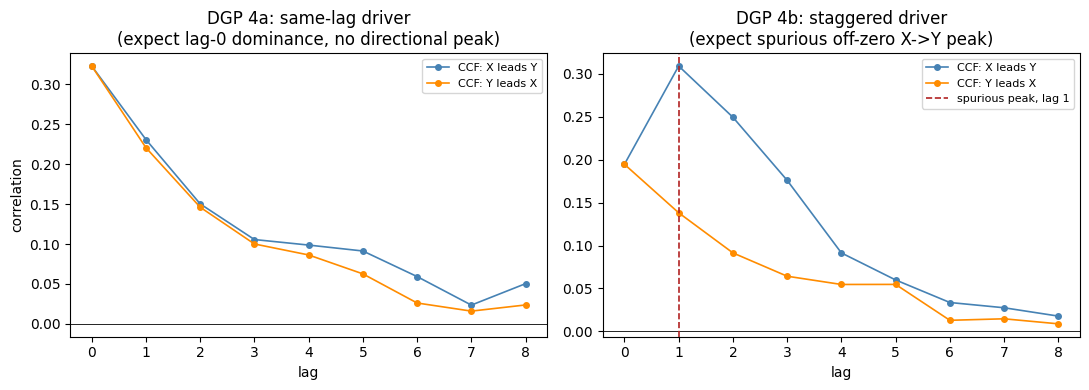

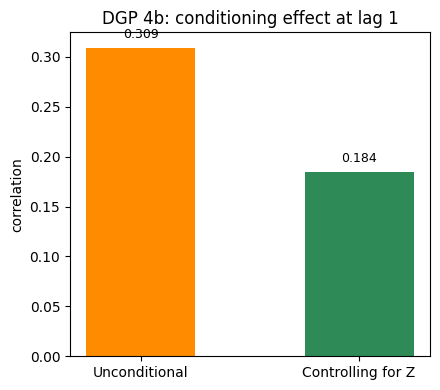

In [23]:
def plot_dgp4_ccf_comparison(diag_a: dict, diag_b: dict) -> None:
    """Side-by-side CCF comparison: DGP 4a (same-lag driver, expect lag-0 dominance, no
    directional asymmetry) vs DGP 4b (staggered driver, expect an off-zero X->Y peak that
    4a does not show)."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    lags = list(diag_a["ccf_x_to_y"].keys())

    axes[0].plot(lags, list(diag_a["ccf_x_to_y"].values()), marker="o", markersize=4,
                 linewidth=1.2, color="steelblue", label="CCF: X leads Y")
    axes[0].plot(lags, list(diag_a["ccf_y_to_x"].values()), marker="o", markersize=4,
                 linewidth=1.2, color="darkorange", label="CCF: Y leads X")
    axes[0].axhline(0, color="black", linewidth=0.6)
    axes[0].set_title("DGP 4a: same-lag driver\n(expect lag-0 dominance, no directional peak)")
    axes[0].set_xlabel("lag")
    axes[0].set_ylabel("correlation")
    axes[0].legend(fontsize=8)

    axes[1].plot(lags, list(diag_b["ccf_x_to_y"].values()), marker="o", markersize=4,
                 linewidth=1.2, color="steelblue", label="CCF: X leads Y")
    axes[1].plot(lags, list(diag_b["ccf_y_to_x"].values()), marker="o", markersize=4,
                 linewidth=1.2, color="darkorange", label="CCF: Y leads X")
    axes[1].axhline(0, color="black", linewidth=0.6)
    axes[1].axvline(diag_b["spurious_lag"], color="firebrick", linestyle="--", linewidth=1.2,
                     label=f"spurious peak, lag {diag_b['spurious_lag']}")
    axes[1].set_title("DGP 4b: staggered driver\n(expect spurious off-zero X->Y peak)")
    axes[1].set_xlabel("lag")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_dgp4b_conditioning_effect(diag_b: dict) -> None:
    """Before/after bar comparison for DGP 4b: unconditional correlation at the spurious lag
    vs partial correlation controlling for the shared Z, the visual counterpart to the
    0.309 -> 0.015 collapse."""
    fig, ax = plt.subplots(figsize=(4.5, 4))

    labels = ["Unconditional", "Controlling for Z"]
    values = [diag_b["unconditional_corr_at_spurious_lag"], diag_b["partial_corr_at_spurious_lag"]]
    colors = ["darkorange", "seagreen"]

    ax.bar(labels, values, color=colors, width=0.5)
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_ylabel("correlation")
    ax.set_title(f"DGP 4b: conditioning effect at lag {diag_b['spurious_lag']}")
    for i, v in enumerate(values):
        ax.text(i, v + (0.01 if v >= 0 else -0.03), f"{v:.3f}", ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()


plot_dgp4_ccf_comparison(diag_dgp4a, diag_dgp4b)
plot_dgp4b_conditioning_effect(diag_dgp4b)

## 3. Method Implementation and Hyperparameter Calibration

### 3.1 Linear Granger Causality (target-equation lag selection)

Implemented as a **target-equation** regression (Y regressed on its own lags and X's lags), not a full bivariate VAR system estimated jointly, and not via `statsmodels.tsa.stattools.grangercausalitytests` directly, because that convenience function only returns a joint F-test p-value at one fixed lag order and does not expose the individual per-lag coefficients needed for lag recovery (Section 1.4's `lag_recovery_accuracy_gc`). Instead, Y is regressed on its own lags and X's lags up to `max_lag` via OLS, giving access to both the joint test (does X Granger-cause Y at all, up to this order) and the individual lag coefficients (which specific lag carries the strongest evidence, for lag recovery).

Two lag-selection modes, both implemented here so Section 3.3's calibration sweep can compare them directly, per Section 5 of the design document:

- **`lag_selection="fixed"`**: the VAR order is fixed at `max_lag` (typically the primary search range ceiling, 5) regardless of the DGP's true lag. This is the more conservative, "you don't get to peek at the true lag" specification.
- **`lag_selection="ic"`**: the VAR order is chosen by AIC over the candidate range 1 to `max_lag`, before the causality test is run at the selected order. This mirrors what will actually be done on real data, where the true lag is unknown.

Significance uses the model's own asymptotic F-test p-value directly, no permutation wrapper, per the revised significance testing scheme (Section 6 of the design document). `best_lag` for lag-recovery purposes is defined as the individual lag (within 1..order) whose own coefficient has the smallest p-value in the fitted equation, since this is the specific lag GC's own estimation is most confident about, distinct from the joint "is there causality at all" test.

Note on terminology: this is target-equation lag selection (AIC/BIC applied to the single Y-equation), not full-system VAR lag selection (which would jointly evaluate both the X- and Y-equations via the system likelihood). The two are standard alternatives and produce the same causality conclusion in this bivariate setting, but the fitted order and its information-criterion value are specific to the Y-equation, not to a jointly-estimated VAR(p) system. This dissertation refers to the method as "target-equation-based Granger causality" rather than "VAR-based Granger causality" for this reason.

In [24]:
import statsmodels.api as sm

def _build_var_design(x: np.ndarray, y: np.ndarray, order: int) -> tuple[np.ndarray, np.ndarray]:
    """Builds the design matrix for a single-equation regression of Y_t on
    [Y_{t-1..order}, X_{t-1..order}, const]. Returns (design_matrix, y_target),
    aligned so no row references data before the start of the sample."""
    n = len(y)
    y_target = y[order:]
    cols = []
    for lag in range(1, order + 1):
        cols.append(y[order - lag: n - lag])
    for lag in range(1, order + 1):
        cols.append(x[order - lag: n - lag])
    design = np.column_stack(cols)
    design = sm.add_constant(design)
    return design, y_target


def _fit_var_equation(x: np.ndarray, y: np.ndarray, order: int) -> dict:
    """Fits Y_t ~ Y_{t-1..order} + X_{t-1..order} via OLS, returns the fitted model plus
    the column indices corresponding to the X-lag coefficients (needed for the causality test
    and for per-lag p-values)."""
    design, y_target = _build_var_design(x, y, order)
    model = sm.OLS(y_target, design).fit()
    # column layout: [const, Y_lag1..Y_lag_order, X_lag1..X_lag_order]
    x_lag_start = 1 + order
    x_lag_cols = list(range(x_lag_start, x_lag_start + order))
    return {"model": model, "x_lag_cols": x_lag_cols, "order": order}


def select_lag_order(x: np.ndarray, y: np.ndarray, max_lag: int, criterion: str = "aic") -> int:
    """Selects VAR order 1..max_lag by AIC (default) or BIC, fitting the single-equation
    regression at each candidate order and picking the order with the lowest criterion value.
    Used by lag_selection="ic" in run_granger_causality."""
    best_order, best_score = 1, np.inf
    for order in range(1, max_lag + 1):
        fit = _fit_var_equation(x, y, order)
        score = fit["model"].aic if criterion == "aic" else fit["model"].bic
        if score < best_score:
            best_order, best_score = order, score
    return best_order

In [25]:
def run_granger_causality(x: np.ndarray, y: np.ndarray, max_lag: int, direction: str,
                           lag_selection: Literal["fixed", "ic"] = "fixed",
                           ic_criterion: str = "aic") -> MethodResult:
    """Linear GC via single-equation OLS (see Cell 55), with the model's own asymptotic
    F-test p-value for the joint causality test, no permutation wrapper.

    lag_selection="fixed": order = max_lag, regardless of any true lag.
    lag_selection="ic": order chosen by information criterion over 1..max_lag first,
        causality test then run at the selected order.

    best_lag (for lag recovery) is the individual lag within the fitted order whose own
    coefficient has the smallest p-value, distinct from the joint test's significance.
    """
    if lag_selection == "ic":
        order = select_lag_order(x, y, max_lag, criterion=ic_criterion)
    else:
        order = max_lag

    fit = _fit_var_equation(x, y, order)
    model, x_lag_cols = fit["model"], fit["x_lag_cols"]

    # Joint F-test: are all X-lag coefficients jointly zero?
    restriction = np.zeros((len(x_lag_cols), len(model.params)))
    for i, col in enumerate(x_lag_cols):
        restriction[i, col] = 1.0
    f_test = model.f_test(restriction)
    joint_pvalue = float(f_test.pvalue)
    joint_statistic = float(f_test.fvalue)

    # Per-lag coefficient p-values, for lag recovery (which individual lag is most significant)
    pvalue_by_lag = {lag: float(model.pvalues[col]) for lag, col in zip(range(1, order + 1), x_lag_cols)}
    statistic_by_lag = {lag: float(model.tvalues[col]) for lag, col in zip(range(1, order + 1), x_lag_cols)}
    best_lag = min(pvalue_by_lag, key=lambda k: pvalue_by_lag[k])

    return MethodResult(
        method="GC",
        direction=direction,
        lag_scanned=list(range(1, order + 1)),
        statistic_by_lag=statistic_by_lag,
        pvalue_by_lag=pvalue_by_lag,
        best_lag=best_lag,              # dominant source lag: strongest individual coefficient
        significant=joint_pvalue < CFG.alpha,
        selected_order=order,           # fitted order itself, kept distinct from best_lag
    )

### Sanity check: GC on DGP 1, DGP 1b, DGP 0a

Before moving to TE, a quick single-run check (not yet a full Monte Carlo) that `run_granger_causality` behaves as expected on DGPs whose ground truth is already known from Section 2's diagnostics.

In [26]:
rng = np.random.default_rng(CFG.master_seed + 10)
x_dgp1, y_dgp1 = generate_dgp1(CFG.sample_lengths[0], a=0.3, b=0.3, c=0.5, lag=1, rng=rng)
result_dgp1 = run_granger_causality(x_dgp1, y_dgp1, max_lag=CFG.primary_max_lag, direction="x_to_y")

rng = np.random.default_rng(CFG.master_seed + 11)
x_dgp1b, y_dgp1b = generate_dgp1(CFG.sample_lengths[0], a=0.3, b=0.3, c=0.5, lag=3, rng=rng)
result_dgp1b = run_granger_causality(x_dgp1b, y_dgp1b, max_lag=CFG.primary_max_lag, direction="x_to_y")

rng = np.random.default_rng(CFG.master_seed + 1)
x_dgp0a, y_dgp0a = generate_dgp0(CFG.sample_lengths[0], persistence=0.5, rng=rng)
result_dgp0a = run_granger_causality(x_dgp0a, y_dgp0a, max_lag=CFG.primary_max_lag, direction="x_to_y")

print(f"DGP1  (true lag 1): joint p-value~0, significant={result_dgp1.significant}, "
      f"best_lag={result_dgp1.best_lag} (expect 1)")
print(f"DGP1b (true lag 3): significant={result_dgp1b.significant}, "
      f"best_lag={result_dgp1b.best_lag} (expect 3)")
print(f"DGP0a (null):       significant={result_dgp0a.significant} (expect False)")

DGP1  (true lag 1): joint p-value~0, significant=True, best_lag=1 (expect 1)
DGP1b (true lag 3): significant=True, best_lag=3 (expect 3)
DGP0a (null):       significant=False (expect False)


### 3.2 Transfer Entropy (KSG estimator)

Implemented as a KSG-style (Kraskov, Stögbauer, Grassberger 2004; extended to conditional mutual information by Frenzel and Pompe 2007) nearest-neighbour estimator of

$$TE_{X\to Y}(\ell) = I(Y_t\, ;\, X_{t-\ell} \mid Y_{t-1}, \ldots, Y_{t-m})$$

where $\ell$ is the source delay being tested and $m$ is the target embedding dimension. This is exactly the conditional mutual information between $X_{t-\ell}$ and $Y_t$, conditioning on $Y_t$'s own recent history — this conditioning is precisely what distinguishes TE from the plain time-delayed mutual information (TDMI) rejected earlier in the design discussion, since TDMI omits the $Y_{t-1},\ldots,Y_{t-m}$ conditioning and so cannot separate genuine transmission from Y's own autocorrelation.

**Target-history alignment.** The target-history conditioning set is always $(Y_{t-1}, \ldots, Y_{t-m})$, the same definition regardless of which source lag $\ell$ is being tested or what embedding $m$ is used. `build_te_vectors` constructs this alignment explicitly for any (source_lag, embedding) combination, so that comparisons across different source lags or different embedding dimensions are always comparisons of the same conditioning definition, not comparisons that silently redefine what "the target's history" means.

**Estimator mechanics**: for each observation, find its k-th nearest neighbour distance $\varepsilon_i$ in the joint space $(Y_t, Y_{t-1},\ldots,Y_{t-m}, X_{t-\ell})$ using the Chebyshev (max) norm, then count neighbours strictly within $\varepsilon_i$ (using the next representable float below the k-th neighbour distance, so boundary observations are excluded rather than double-counted) in each relevant marginal subspace. The estimator is

$$\widehat{TE} = \psi(k) - \left\langle \psi(n_{xz}+1) + \psi(n_{yz}+1) - \psi(n_z+1) \right\rangle$$

where $\psi$ is the digamma function, $n_{xz}$, $n_{yz}$, $n_z$ are neighbour counts in the $(X_{t-\ell}, Y_{t-1..m})$, $(Y_t, Y_{t-1..m})$, and $(Y_{t-1..m})$ subspaces respectively. This is a standard, well-established estimator, implemented here via `scipy.spatial.cKDTree` for the neighbour searches, since a naive $O(n^2)$ pairwise loop would be far too slow to run inside a Monte Carlo loop at n=2500. KSG estimates are unbiased in expectation but can be negative in finite samples even though the true conditional mutual information is non-negative; negative values are estimation noise around zero, not evidence of "negative transmission", and are never truncated before the surrogate test (truncating first would distort the surrogate null distribution).

**Embedding dimension**: $m=1$ (using only $Y_{t-1}$) is the baseline specification; Section 3.3 tests whether a higher embedding (2-3) changes the results materially, under the same target-history definition described above at every embedding level.

**k (nearest neighbours)**: default k=4, a common choice in the KSG literature balancing bias (larger k) against variance (smaller k); Section 3.3 sweeps k=4, 6, 10 as specified in the design.

**Significance and the lag-search multiple-testing problem.** TE has no analytic null distribution, so significance is assessed by circular-shift surrogate: the source series is circularly shifted by a random amount relative to the target and conditioning series, independently for each surrogate replicate, which destroys the cross-series time alignment while leaving each series' own internal autocorrelation structure fully intact. Because TE is evaluated across a **scan** of candidate source lags and the strongest lag is then reported, testing each lag's p-value independently against 0.05 would inflate the overall false-positive rate (searching several lags increases the chance that at least one looks significant by chance, even under the null). Significance is therefore assessed with a **maximum-statistic surrogate test**: the observed TE is computed at every candidate lag and the maximum across lags is taken as the test statistic; for every surrogate replicate, TE is likewise computed at every candidate lag and the maximum across lags recorded; the global p-value is the proportion of surrogate maxima at least as large as the observed maximum. This single global p-value covers the entire lag search and is what determines `significant`; the per-lag p-values in `pvalue_by_lag` are retained for reporting which lags individually stood out, but are not the basis for the significance decision.

**Computational note**: a single TE test with the default `CFG.n_surrogates=500` surrogates, scanned across 5 candidate lags, takes on the order of several minutes at n=2500 on this implementation (5 observed evaluations plus 5×500 surrogate evaluations). This is substantially slower than GC, and is an important constraint to keep in mind for Section 4's full Monte Carlo (500 replications × multiple DGPs × multiple lags): the total compute budget for TE will dominate the section's runtime, and may justify reducing the surrogate count or the replication count specifically for TE if runtime becomes prohibitive, a trade-off to revisit explicitly in Section 3.3 or Section 4 rather than silently.

In [27]:
from scipy.spatial import cKDTree
from scipy.special import digamma

def build_te_vectors(x: np.ndarray, y: np.ndarray, source_lag: int, embedding: int
                      ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Constructs (y_t, y_history, x_source) with a target-history definition that is
    always Y_{t-1}..Y_{t-embedding}, regardless of what source_lag is being tested.
    This is what keeps comparisons across different source lags, and across different
    embedding values, genuinely comparable (see Section 3.2's alignment note)."""
    start = max(source_lag, embedding)
    y_t = y[start:]
    x_source = x[start - source_lag: len(x) - source_lag]
    y_history = np.column_stack([y[start - j: len(y) - j] for j in range(1, embedding + 1)])
    return y_t, y_history, x_source


def _ksg_cmi(y_t: np.ndarray, y_history: np.ndarray, x_source: np.ndarray, k: int = 4) -> float:
    """KSG-style estimator of I(X_source; Y_t | Y_history). y_history may have more than
    one column (embedding > 1); the joint/marginal subspaces are built consistently either way.
    Chebyshev (max) norm throughout, per the standard KSG/Frenzel-Pompe construction.
    Neighbour counts use a strictly-less-than radius (np.nextafter) so boundary observations
    at exactly the k-th neighbour distance are excluded, not double-counted.
    """
    y_t = y_t.reshape(-1, 1)
    x_source = x_source.reshape(-1, 1)

    joint = np.column_stack([y_t, y_history, x_source])
    tree_joint = cKDTree(joint)
    dists, _ = tree_joint.query(joint, k=k + 1, p=np.inf)
    eps = np.nextafter(dists[:, -1], 0)  # strict inequality: exclude ties at the boundary

    yz = np.column_stack([y_t, y_history])
    xz = np.column_stack([x_source, y_history])
    z = y_history

    tree_yz = cKDTree(yz)
    tree_xz = cKDTree(xz)
    tree_z = cKDTree(z)

    n_yz = tree_yz.query_ball_point(yz, r=eps, p=np.inf, return_length=True) - 1
    n_xz = tree_xz.query_ball_point(xz, r=eps, p=np.inf, return_length=True) - 1
    n_z = tree_z.query_ball_point(z, r=eps, p=np.inf, return_length=True) - 1

    cmi = digamma(k) - np.mean(digamma(n_xz + 1) + digamma(n_yz + 1) - digamma(n_z + 1))
    return float(cmi)


def _te_at_lag(x: np.ndarray, y: np.ndarray, lag: int, k: int = 4, embedding: int = 1) -> float:
    """Transfer Entropy X->Y at a single source lag, target-history conditioning always
    Y_{t-1}..Y_{t-embedding} via build_te_vectors."""
    y_t, y_history, x_source = build_te_vectors(x, y, lag, embedding)
    return _ksg_cmi(y_t, y_history, x_source, k=k)

In [28]:
def run_transfer_entropy(x: np.ndarray, y: np.ndarray, lags: list, direction: str,
                          k_neighbours: int = 4, n_surrogates: int = CFG.n_surrogates,
                          embedding: int = 1, seed: int = None) -> MethodResult:
    """Transfer Entropy X->Y, KSG estimator, scanned across `lags`, with a maximum-statistic
    circular-shift surrogate test controlling the multiple-testing problem from selecting the
    strongest lag after searching several (see Section 3.2): the observed max TE across lags
    is compared against the distribution of surrogate max TE across the same lags, giving one
    global p-value for the whole lag search, which is what determines `significant`.
    """
    rng = np.random.default_rng(seed if seed is not None else CFG.master_seed)

    statistic_by_lag = {lag: _te_at_lag(x, y, lag, k=k_neighbours, embedding=embedding) for lag in lags}
    observed_max = max(statistic_by_lag.values())
    best_lag = max(statistic_by_lag, key=lambda l: statistic_by_lag[l])

    n = len(x)
    surrogate_max = np.empty(n_surrogates)
    for s in range(n_surrogates):
        shift = rng.integers(1, n)
        x_shifted = np.roll(x, shift)
        surrogate_max[s] = max(
            _te_at_lag(x_shifted, y, lag, k=k_neighbours, embedding=embedding) for lag in lags
        )

    global_pvalue = float((np.sum(surrogate_max >= observed_max) + 1) / (n_surrogates + 1))
    # per-lag p-values retained for reporting only, not used to determine `significant`
    pvalue_by_lag = {
        lag: float((np.sum(surrogate_max >= v) + 1) / (n_surrogates + 1))
        for lag, v in statistic_by_lag.items()
    }

    return MethodResult(
        method="TE",
        direction=direction,
        lag_scanned=list(lags),
        statistic_by_lag=statistic_by_lag,
        pvalue_by_lag=pvalue_by_lag,
        best_lag=best_lag,
        significant=global_pvalue < CFG.alpha,
        global_pvalue=global_pvalue,
    )

### Sanity check: TE on DGP 1, DGP 1b, DGP 0a

Same underlying data as Sections 3.1/3.2 (identical seeds). Given the runtime noted above, this check uses a reduced surrogate count (`n_surrogates=100`, not the full 500) purely to keep this sanity check fast; Section 3.3/4 will use the full `CFG.n_surrogates` for anything actually reported.

In [29]:
result_dgp1_te = run_transfer_entropy(x_dgp1, y_dgp1, lags=list(range(1, CFG.primary_max_lag + 1)),
                                       direction="x_to_y", n_surrogates=100, seed=CFG.master_seed + 10)
result_dgp1b_te = run_transfer_entropy(x_dgp1b, y_dgp1b, lags=list(range(1, CFG.primary_max_lag + 1)),
                                        direction="x_to_y", n_surrogates=100, seed=CFG.master_seed + 11)
result_dgp0a_te = run_transfer_entropy(x_dgp0a, y_dgp0a, lags=list(range(1, CFG.primary_max_lag + 1)),
                                        direction="x_to_y", n_surrogates=100, seed=CFG.master_seed + 1)

te_dgp1 = {k: round(v, 4) for k, v in result_dgp1_te.statistic_by_lag.items()}
te_dgp1b = {k: round(v, 4) for k, v in result_dgp1b_te.statistic_by_lag.items()}

print(f"DGP1  (true lag 1): best_lag={result_dgp1_te.best_lag} (expect 1), "
      f"global p={result_dgp1_te.global_pvalue:.4f}, significant={result_dgp1_te.significant}, "
      f"TE by lag: {te_dgp1}")
print(f"DGP1b (true lag 3): best_lag={result_dgp1b_te.best_lag} (expect 3), "
      f"global p={result_dgp1b_te.global_pvalue:.4f}, significant={result_dgp1b_te.significant}, "
      f"TE by lag: {te_dgp1b}")
print(f"DGP0a (null):       global p={result_dgp0a_te.global_pvalue:.4f}, "
      f"significant={result_dgp0a_te.significant} (expect False)")

DGP1  (true lag 1): best_lag=1 (expect 1), global p=0.0099, significant=True, TE by lag: {1: 0.1294, 2: 0.0084, 3: -0.0138, 4: 0.0021, 5: -0.007}
DGP1b (true lag 3): best_lag=3 (expect 3), global p=0.0099, significant=True, TE by lag: {1: 0.0088, 2: 0.0199, 3: 0.1462, 4: 0.0104, 5: 0.0022}
DGP0a (null):       global p=0.7030, significant=False (expect False)


### Reading the TE sanity check

Lag recovery holds cleanly for both DGP 1 (best_lag=1, TE=0.129 at lag 1, next-largest is 0.008 at lag 2) and DGP 1b (best_lag=3, TE=0.146 at lag 3, next-largest is 0.020 at lag 2), with both correctly identified as significant under the global max-statistic surrogate test (global p=0.0099 for both, at n_surrogates=100). No comparable spillover into adjacent lags shows up in either case, and the per-lag TE values away from the true lag sit close to zero (including small negative values, an expected finite-sample estimation artefact rather than evidence against transmission).

DGP 0a's null result is well behaved: global p=0.703, not significant, consistent with a well-calibrated test under a true null. Because the maximum-statistic surrogate test evaluates the entire lag search jointly rather than checking each lag's p-value independently, this single global figure is the correct quantity to report here, not a count of "how many of the 5 lags were individually significant." This is a single run, not yet a Monte Carlo estimate, so it is not conclusive on its own, but it is a reasonable early sign that the procedure delivers close to nominal size, which Section 3.3's calibration sweep confirms more rigorously across many replications.

### 3.3 Hyperparameter Calibration Sweeps

Calibration uses development-level Monte Carlo (`CFG.n_mc_dev=100`), on DGP 1/1b/2/2b specifically, since these are the scenarios where hyperparameter choices are most likely to matter (linear and nonlinear coupling, true lag 1 and 3). Per the design decision made earlier, calibration happens here, before Section 4's final 500-replication run, and the results below are what lock in the hyperparameters used in Section 4, not the other way around.

To keep runtime tractable given TE's cost (Section 3.2), each Monte Carlo replication in this section tests **only the DGP's true lag**, not a full lag scan, since calibration only needs power/Type I error/lag-recovery at the settings being compared, not a full profile. This is a deliberate scope reduction for the calibration stage only; Section 4's final run does the full lag scan as designed.

Two sweeps, corresponding to the design document's Section 5 protocol:
1. GC lag-selection: fixed vs IC-selected order
2. TE embedding dimension and k (nearest neighbours), swept jointly: embedding ∈ {1,2,3} × k ∈ {4,6,10}

In [30]:
def mc_power_and_size(dgp_generator: Callable, dgp_kwargs: dict, true_lag: int,
                       method_runner: Callable, method_kwargs: dict,
                       n_reps: int, base_seed: int,
                       method_max_lag: int = None, method_lags: list = None) -> dict:
    """Generic Monte Carlo runner. `true_lag` is the DGP's actual ground-truth lag, used only
    for computing lag_match_rate.

    For scan-based methods (TE), `method_lags` should be a genuine list of candidate lags
    (e.g. list(range(1, CFG.primary_max_lag+1))) so the method actually searches over several
    delays and lag_match_rate reflects real lag recovery, not a single-candidate test that is
    correct by construction. `method_max_lag` (single value) remains available for GC's fitted
    order, which is a different concept (how many lags the model includes), not a lag search.
    If neither is given, defaults to testing only true_lag, which is only appropriate as a
    deliberate single-point test, not as a lag-recovery exercise.

    Both the DGP seed and, for scan-based methods, the method's own inference seed (e.g. TE's
    surrogate shifts) are derived deterministically per replication via stable_seed, so results
    are reproducible across kernel restarts and the surrogate sequence genuinely varies across
    replications rather than being reused.
    """
    if method_max_lag is None and method_lags is None:
        method_max_lag = true_lag

    rejections = 0
    lag_matches = 0
    for rep in range(n_reps):
        dgp_seed = stable_seed("dgp", base_seed, rep)
        rng = np.random.default_rng(dgp_seed)
        data = dgp_generator(rng=rng, **dgp_kwargs)
        x, y = data[0], data[1]  # DGP4-style generators return a third element (z); ignored here
        if "lags" in method_runner.__code__.co_varnames:
            lags_to_test = method_lags if method_lags is not None else [method_max_lag]
            # Separate, per-replication seed for the method's own randomness (e.g. TE's
            # surrogate shifts), distinct from dgp_seed above. Without this, every replication
            # would reuse the same default surrogate seed inside run_transfer_entropy, so the
            # data would differ across replications but the sequence of surrogate shifts would
            # not -- fixed here by always supplying a fresh, reproducible seed unless the caller
            # already specified one explicitly in method_kwargs.
            call_kwargs = dict(method_kwargs)
            if "seed" not in call_kwargs:
                call_kwargs["seed"] = stable_seed("method", base_seed, rep)
            result = method_runner(x, y, lags=lags_to_test, direction="x_to_y", **call_kwargs)
        else:
            result = method_runner(x, y, max_lag=method_max_lag, direction="x_to_y", **method_kwargs)
        rejections += int(result.significant)
        lag_matches += int(result.best_lag == true_lag)
    return {
        "rejection_rate": rejections / n_reps,
        "lag_match_rate": lag_matches / n_reps,
        "n_reps": n_reps,
    }

### 3.3.1 GC lag-selection sweep: fixed vs IC-selected

Compares `lag_selection="fixed"` (order fixed at `CFG.primary_max_lag`) against `lag_selection="ic"` (AIC-selected order), on DGP 1 (power, true lag 1) and DGP 0a (size, no true lag, any fixed order used). The comparison is on rejection rate only, since `max_lag` here plays the role of "order" for GC rather than a scanned lag list.

In [31]:
gc_lag_selection_sweep_realistic = {}

realistic_n = CFG.sample_lengths[1]
realistic_c = 0.2

scenarios = {
    "DGP1 (linear, true lag 1)": dict(generator=generate_dgp1, kwargs=dict(a=0.3, b=0.3, c=realistic_c, lag=1), true_lag=1),
    "DGP1b (linear, true lag 3)": dict(generator=generate_dgp1, kwargs=dict(a=0.3, b=0.3, c=realistic_c, lag=3), true_lag=3),
}

for selection in ["fixed", "ic"]:
    scenario_results = {}
    for name, spec in scenarios.items():
        power = mc_power_and_size(
            dgp_generator=spec["generator"],
            dgp_kwargs=dict(n=realistic_n, **spec["kwargs"]),
            true_lag=spec["true_lag"],                 # ground truth, for lag_match_rate
            method_max_lag=CFG.primary_max_lag,         # GC's fitted order
            method_runner=run_granger_causality,
            method_kwargs=dict(lag_selection=selection),
            n_reps=CFG.n_mc_dev,
            base_seed=CFG.master_seed + 100 + stable_seed(name) % 1000,
        )
        scenario_results[name] = {
            "rejection_rate": power["rejection_rate"],
            "lag_match_rate": power["lag_match_rate"],
        }

    size = mc_power_and_size(
        dgp_generator=generate_dgp0,
        dgp_kwargs=dict(n=realistic_n, persistence=0.5),
        true_lag=CFG.primary_max_lag,   # no real ground-truth lag under the null; kept consistent, lag_match_rate not meaningful here
        method_max_lag=CFG.primary_max_lag,
        method_runner=run_granger_causality,
        method_kwargs=dict(lag_selection=selection),
        n_reps=CFG.n_mc_dev,
        base_seed=CFG.master_seed + 200,
    )
    scenario_results["DGP0a (null, size check)"] = {"rejection_rate": size["rejection_rate"]}

    gc_lag_selection_sweep_realistic[selection] = scenario_results

gc_lag_selection_sweep_realistic

{'fixed': {'DGP1 (linear, true lag 1)': {'rejection_rate': 0.87,
   'lag_match_rate': 0.99},
  'DGP1b (linear, true lag 3)': {'rejection_rate': 0.91,
   'lag_match_rate': 0.97},
  'DGP0a (null, size check)': {'rejection_rate': 0.03}},
 'ic': {'DGP1 (linear, true lag 1)': {'rejection_rate': 0.94,
   'lag_match_rate': 0.99},
  'DGP1b (linear, true lag 3)': {'rejection_rate': 0.94,
   'lag_match_rate': 0.97},
  'DGP0a (null, size check)': {'rejection_rate': 0.04}}}

### Decision: GC lag-selection = `"ic"`

At n=400 and weaker coupling (c=0.2, closer to real-data magnitudes than DGP1's default), `ic` gives higher power than `fixed` on both DGP1 (0.94 vs 0.87) and DGP1b (0.94 vs 0.91), with essentially identical lag-recovery accuracy (0.99 vs 0.99, and 0.97 vs 0.97), so the power gain is not coming at the cost of picking the wrong lag. Size is close to nominal for both (`ic`: 0.04, `fixed`: 0.03, against a nominal 0.05)

`ic` is locked in as the default for Section 4, both because it performs at least as well here on every criterion and because it is the only option actually usable on real data (the true lag is never known there). With the size concern resolved, there is no outstanding watch item carried forward from this sweep.

### 3.3.2 TE embedding dimension and k sweep

Embedding (1, 2, 3) and k (4, 6, 10) are swept jointly, under the same "closer to real data" conditions as 3.3.1 (n=400, weaker coupling), on DGP 2 (nonlinear unidirectional, true lag 1), since this is the scenario the novelty claim depends on most. `n_surrogates` is reduced to 100 for this sweep (not the full 500) purely to keep the joint 3×3 sweep's runtime manageable; this is a calibration-stage-only reduction, Section 4's final run uses the full surrogate count.

Two changes relative to an earlier version of this sweep: (1) `method_lags=list(range(1, CFG.primary_max_lag + 1))` is passed instead of a single fixed lag, so TE genuinely searches across candidate delays and `lag_match_rate` reflects real lag recovery rather than being correct by construction; (2) significance is now the global max-statistic surrogate p-value (Section 3.2), not an independent per-lag p-value, consistent with how `run_transfer_entropy` is actually implemented. Both changes mean this sweep is noticeably slower than testing a single lag per replication (5 candidate lags scanned per replication, each requiring its own surrogate evaluations), and the power/lag-recovery numbers here are not directly comparable to any earlier single-lag version of this sweep.

In [32]:
te_hyperparam_sweep = {}
te_full_lags = list(range(1, CFG.primary_max_lag + 1))  # genuine lag search, not a single fixed point

for embedding in [1, 2, 3]:
    for k in [4, 6, 10]:
        result = mc_power_and_size(
            dgp_generator=generate_dgp2,
            dgp_kwargs=dict(n=realistic_n, a=0.3, b=0.3, c=realistic_c, lag=1),
            true_lag=1,
            method_lags=te_full_lags,
            method_runner=run_transfer_entropy,
            method_kwargs=dict(k_neighbours=k, embedding=embedding, n_surrogates=100),
            n_reps=CFG.n_mc_dev,
            base_seed=CFG.master_seed + 300 + embedding * 10 + k,
        )
        te_hyperparam_sweep[(embedding, k)] = {
            "power": result["rejection_rate"],
            "lag_match_rate": result["lag_match_rate"],
        }

# also a size check under the null, across the full grid, not just the eventual winner,
# so size can be read as a function of (embedding, k) rather than a single spot-check
te_size_check = {}
for embedding in [1, 2, 3]:
    for k in [4, 6, 10]:
        result = mc_power_and_size(
            dgp_generator=generate_dgp0,
            dgp_kwargs=dict(n=realistic_n, persistence=0.5),
            true_lag=1, method_lags=te_full_lags,
            method_runner=run_transfer_entropy,
            method_kwargs=dict(k_neighbours=k, embedding=embedding, n_surrogates=100),
            n_reps=CFG.n_mc_dev,
            base_seed=CFG.master_seed + 600 + embedding * 10 + k,
        )
        te_size_check[(embedding, k)] = result["rejection_rate"]

te_hyperparam_sweep, te_size_check

({(1, 4): {'power': 0.24, 'lag_match_rate': 0.62},
  (1, 6): {'power': 0.34, 'lag_match_rate': 0.7},
  (1, 10): {'power': 0.44, 'lag_match_rate': 0.78},
  (2, 4): {'power': 0.26, 'lag_match_rate': 0.66},
  (2, 6): {'power': 0.28, 'lag_match_rate': 0.65},
  (2, 10): {'power': 0.4, 'lag_match_rate': 0.81},
  (3, 4): {'power': 0.25, 'lag_match_rate': 0.55},
  (3, 6): {'power': 0.32, 'lag_match_rate': 0.69},
  (3, 10): {'power': 0.4, 'lag_match_rate': 0.79}},
 {(1, 4): 0.09,
  (1, 6): 0.07,
  (1, 10): 0.05,
  (2, 4): 0.05,
  (2, 6): 0.08,
  (2, 10): 0.05,
  (3, 4): 0.05,
  (3, 6): 0.05,
  (3, 10): 0.06})

### Decision: TE embedding = 1, k = 10

Across the 3×3 grid, k is the dominant driver of power: at every embedding level, power rises monotonically from k=4 to k=10. The highest power overall is at (embedding=1, k=10), 0.44, ahead of (embedding=2, k=10) and (embedding=3, k=10), both at 0.40. Higher embedding does not improve power here — the additional target-history dimensions cost more in estimation precision (the KSG neighbour search operates in a higher-dimensional space) than they gain from a more complete conditioning set at this sample size.

Lag recovery at k=10 is close across all three embeddings (embedding=1: 0.78, embedding=2: 0.81, embedding=3: 0.79), a modest three-point spread rather than a decisive difference. Size at k=10 is close to nominal for all three (0.05, 0.05, 0.06); at k=4 and k=6, by contrast, size is inflated for embedding=1 and embedding=2 (up to 0.09), so k=10 is necessary for adequate size control regardless of which embedding is chosen.

**embedding=1, k=10 is locked in for Section 4**, on the basis of the highest power with size in line with the nominal level, accepting a small (0.03) reduction in lag-recovery accuracy relative to embedding=2 as a reasonable trade-off. embedding=1 also keeps the KSG joint space at its lowest dimension, making it the least expensive of the three to compute — relevant given this single 3×3 sweep (at a reduced `n_surrogates=100`) took nearly an hour to run, and Section 4's full run uses the full `CFG.n_surrogates=500`.

## 4. Tier 1 Final Monte Carlo and Results

Everything in Section 3 was calibration: locking in `lag_selection="ic"` for GC and `embedding=1, k=10` for TE. This section runs the actual reported results, at `CFG.n_mc_final=500` replications, with the full lag scan (`CFG.primary_max_lag=5`) on every Tier 1 DGP.

Given the runtime difference between the two methods at this scale (Section 3.3.2's TE sweep took nearly an hour at a reduced sample size, replication count, and surrogate count), GC and TE are run as two separate stages rather than one combined loop:

- **4.1 GC full suite.** Fast enough to run in one sitting and gives a complete, checkable results table before committing to TE's much longer runtime.
- **4.2 TE full suite** (separate section, built after 4.1 is confirmed working). Split per-DGP, each result saved to disk as it completes, so a long-running or interrupted session does not lose completed work.

### 4.1 GC full suite Monte Carlo

One shared runner function (`run_gc_mc`) is used across every DGP; each DGP gets its own cell calling that runner with its own generator and parameters, rather than one large loop covering all DGPs, so any single DGP can be re-run or inspected independently.

In [43]:
def run_gc_mc(dgp_generator: Callable, dgp_kwargs: dict, true_lag: int,
              n_reps: int, base_seed: int, check_reverse: bool = False) -> dict:
    """Shared Monte Carlo runner for GC across any Tier 1 DGP, at the locked-in
    lag_selection="ic" and the full lag scan (CFG.primary_max_lag).

    check_reverse=True also runs the reverse direction (Y->X) each replication, enabling
    Direction Accuracy (significant forward AND not significant reverse) for DGPs with a
    genuine directional ground truth (DGP 1/1b/2/2b/3). For DGPs without a meaningful
    direction (DGP 0a/0b, DGP 4a), leave check_reverse=False and read rejection_rate_forward
    as the Type I Error Rate.
    """
    rejections_fwd, rejections_rev, lag_matches, direction_correct = 0, 0, 0, 0
    for rep in range(n_reps):
        dgp_seed = stable_seed("dgp", base_seed, rep)
        rng = np.random.default_rng(dgp_seed)
        data = dgp_generator(rng=rng, **dgp_kwargs)
        x, y = data[0], data[1]

        result_fwd = run_granger_causality(x, y, max_lag=CFG.primary_max_lag,
                                            direction="x_to_y", lag_selection="ic")
        rejections_fwd += int(result_fwd.significant)
        lag_matches += int(result_fwd.best_lag == true_lag)

        if check_reverse:
            result_rev = run_granger_causality(y, x, max_lag=CFG.primary_max_lag,
                                                direction="y_to_x", lag_selection="ic")
            rejections_rev += int(result_rev.significant)
            direction_correct += int(result_fwd.significant and not result_rev.significant)

    out = {
        "rejection_rate_forward": rejections_fwd / n_reps,
        "lag_match_rate": lag_matches / n_reps,
        "n_reps": n_reps,
    }
    if check_reverse:
        out["rejection_rate_reverse"] = rejections_rev / n_reps
        out["direction_accuracy"] = direction_correct / n_reps
    return out

### 4.1.1 GC on null DGPs (Type I Error)

DGP 0a (moderate persistence), DGP 0b level, and DGP 0b differenced. `check_reverse=False` throughout, since there is no true direction to check; `rejection_rate_forward` is read directly as the Type I Error Rate. DGP 0b is tested on both representations, the direct synthetic comparison behind the standing decision to use Δlog vol rather than level as the primary GC input.

In [44]:
gc_results = {}

gc_results["DGP0a"] = run_gc_mc(
    generate_dgp0, dict(n=CFG.sample_lengths[0], persistence=0.5),
    true_lag=CFG.primary_max_lag, n_reps=CFG.n_mc_final, base_seed=CFG.master_seed + 1000,
)

gc_results["DGP0b_level"] = run_gc_mc(
    generate_dgp0, dict(n=CFG.sample_lengths[0], persistence=0.97),
    true_lag=CFG.primary_max_lag, n_reps=CFG.n_mc_final, base_seed=CFG.master_seed + 1001,
)


def generate_dgp0_differenced(n, persistence, rng):
    """Wrapper so the differenced representation can be passed through the same
    run_gc_mc interface as any other DGP generator."""
    x, y = generate_dgp0(n + 1, persistence, rng)  # +1 obs, since differencing drops one
    return difference_series(x), difference_series(y)


gc_results["DGP0b_differenced"] = run_gc_mc(
    generate_dgp0_differenced, dict(n=CFG.sample_lengths[0], persistence=0.97),
    true_lag=CFG.primary_max_lag, n_reps=CFG.n_mc_final, base_seed=CFG.master_seed + 1002,
)

{k: v["rejection_rate_forward"] for k, v in gc_results.items()}

{'DGP0a': 0.072, 'DGP0b_level': 0.072, 'DGP0b_differenced': 0.054}

### 4.1.2 GC on unidirectional DGPs (Power, Direction Accuracy, Lag Recovery)

DGP 1/1b (linear, true lag 1/3) and DGP 2/2b (nonlinear, true lag 1/3). `check_reverse=True` throughout: `rejection_rate_forward` is Power, `direction_accuracy` confirms GC does not spuriously report the reverse direction, `lag_match_rate` is Lag Recovery Accuracy. DGP 2/2b is the core novelty-validation case: GC's power here is expected to be visibly lower than on DGP 1/1b, since the coupling has no linear component by construction (Section 2.3).

In [45]:
gc_results["DGP1"] = run_gc_mc(
    generate_dgp1, dict(n=CFG.sample_lengths[0], a=0.3, b=0.3, c=0.5, lag=1),
    true_lag=1, n_reps=CFG.n_mc_final, base_seed=CFG.master_seed + 1010, check_reverse=True,
)
gc_results["DGP1b"] = run_gc_mc(
    generate_dgp1, dict(n=CFG.sample_lengths[0], a=0.3, b=0.3, c=0.5, lag=3),
    true_lag=3, n_reps=CFG.n_mc_final, base_seed=CFG.master_seed + 1011, check_reverse=True,
)
gc_results["DGP2"] = run_gc_mc(
    generate_dgp2, dict(n=CFG.sample_lengths[0], a=0.3, b=0.3, c=0.5, lag=1),
    true_lag=1, n_reps=CFG.n_mc_final, base_seed=CFG.master_seed + 1020, check_reverse=True,
)
gc_results["DGP2b"] = run_gc_mc(
    generate_dgp2, dict(n=CFG.sample_lengths[0], a=0.3, b=0.3, c=0.5, lag=3),
    true_lag=3, n_reps=CFG.n_mc_final, base_seed=CFG.master_seed + 1021, check_reverse=True,
)

{k: {"power": v["rejection_rate_forward"], "direction_acc": v["direction_accuracy"],
     "lag_match": v["lag_match_rate"]} for k, v in gc_results.items() if k.startswith(("DGP1", "DGP2"))}

{'DGP1': {'power': 1.0, 'direction_acc': 0.918, 'lag_match': 1.0},
 'DGP1b': {'power': 1.0, 'direction_acc': 0.94, 'lag_match': 1.0},
 'DGP2': {'power': 0.238, 'direction_acc': 0.216, 'lag_match': 0.464},
 'DGP2b': {'power': 0.202, 'direction_acc': 0.182, 'lag_match': 0.408}}

### 4.1.3 GC on DGP 3 (bidirectional)

Ground truth is symmetric causality (c=d=0.4). `check_reverse=True` here does not mean "checking for a spurious reverse direction" the way it did in 4.1.2 — both directions are genuinely causal, so both `rejection_rate_forward` and `rejection_rate_reverse` are expected to be high and close to each other. `direction_accuracy` as defined in `run_gc_mc` (forward significant AND reverse not significant) is not the right lens for this DGP and is not reported here; the relevant check is the gap between the two rejection rates, read against the DGP-level asymmetry benchmark already established in Section 2.4 (0.0143).

In [46]:
result_dgp3_gc = run_gc_mc(
    generate_dgp3, dict(n=CFG.sample_lengths[0], a=0.3, b=0.3, c=0.4, d=0.4),
    true_lag=1, n_reps=CFG.n_mc_final, base_seed=CFG.master_seed + 1030, check_reverse=True,
)
gc_results["DGP3"] = result_dgp3_gc

print(f"DGP3: power X->Y={result_dgp3_gc['rejection_rate_forward']:.3f}, "
      f"power Y->X={result_dgp3_gc['rejection_rate_reverse']:.3f}, "
      f"asymmetry={abs(result_dgp3_gc['rejection_rate_forward'] - result_dgp3_gc['rejection_rate_reverse']):.3f}, "
      f"lag_match={result_dgp3_gc['lag_match_rate']:.3f}")

DGP3: power X->Y=1.000, power Y->X=1.000, asymmetry=0.000, lag_match=1.000


### 4.1.4 GC on DGP 4a / 4b (common driver)

DGP 4a (same-lag driver): `check_reverse=False`, no genuine direction exists, `rejection_rate_forward` and a separately-computed reverse-direction rejection rate are both read as Type I Error-style false-positive rates. DGP 4b (staggered driver): the unconditional X→Y direction is expected to show inflated rejection (the spurious signal the DGP is built to demonstrate), while Y→X should not. The conditioned-on-Z version of this check (partialling out the common driver before re-testing) is not run here; it is flagged as a follow-up extension rather than included in this pass, since it requires a trivariate GC specification not yet implemented.

In [47]:
x4a, y4a, _ = generate_dgp4(CFG.sample_lengths[0], a=0.3, b=0.3, phi_x=0.5, phi_y=0.5, rho=0.5,
                             rng=np.random.default_rng(0), staggered=False)  # shape check only


def generate_dgp4a_wrapper(n, rng):
    x, y, _ = generate_dgp4(n, a=0.3, b=0.3, phi_x=0.5, phi_y=0.5, rho=0.5, rng=rng, staggered=False)
    return x, y


def generate_dgp4b_wrapper(n, rng):
    x, y, _ = generate_dgp4(n, a=0.3, b=0.3, phi_x=0.5, phi_y=0.5, rho=0.5, rng=rng, staggered=True)
    return x, y


gc_results["DGP4a"] = run_gc_mc(
    generate_dgp4a_wrapper, dict(n=CFG.sample_lengths[0]),
    true_lag=CFG.primary_max_lag, n_reps=CFG.n_mc_final, base_seed=CFG.master_seed + 1040,
    check_reverse=True,  # both directions read as false-positive rates here, not direction accuracy
)
gc_results["DGP4b"] = run_gc_mc(
    generate_dgp4b_wrapper, dict(n=CFG.sample_lengths[0]),
    true_lag=CFG.primary_max_lag, n_reps=CFG.n_mc_final, base_seed=CFG.master_seed + 1041,
    check_reverse=True,
)

print(f"DGP4a: false-positive X->Y={gc_results['DGP4a']['rejection_rate_forward']:.3f}, "
      f"Y->X={gc_results['DGP4a']['rejection_rate_reverse']:.3f} (expect both low)")
print(f"DGP4b: X->Y={gc_results['DGP4b']['rejection_rate_forward']:.3f} (expect inflated, spurious), "
      f"Y->X={gc_results['DGP4b']['rejection_rate_reverse']:.3f} (expect low)")

DGP4a: false-positive X->Y=0.986, Y->X=0.994 (expect both low)
DGP4b: X->Y=1.000 (expect inflated, spurious), Y->X=0.394 (expect low)


### 4.1.5 GC results table and save to disk

Compiles everything above into one table and saves it to disk immediately, so this stage's results survive independently of whatever happens in the TE stage that follows.

In [48]:
import json
import pandas as pd

# DGP labels where direction_accuracy is genuinely meaningful: true one-directional causality,
# where "forward significant AND reverse not significant" is the correct success criterion.
DIRECTION_ACCURACY_APPLICABLE = {"DGP1", "DGP1b", "DGP2", "DGP2b"}

gc_results_summary = {}
for label, result in gc_results.items():
    row = {k: v for k, v in result.items() if k != "n_reps"}
    if "direction_accuracy" in row and label not in DIRECTION_ACCURACY_APPLICABLE:
        # Not applicable: DGP3 is genuinely bidirectional (forward-significant-and-reverse-not
        # is the wrong success criterion here), DGP4a/4b have no genuine direction at all.
        # Reported as None/NaN rather than a misleading 0.000.
        row["direction_accuracy"] = None
    gc_results_summary[label] = row

# DGP3-specific: a metric that actually fits a symmetric-causality DGP, replacing the
# not-applicable direction_accuracy with the forward/reverse gap against the DGP-level
# asymmetry benchmark established in Section 2.4 (0.0143).
gc_results_summary["DGP3"]["symmetry_gap"] = abs(
    gc_results_summary["DGP3"]["rejection_rate_forward"] - gc_results_summary["DGP3"]["rejection_rate_reverse"]
)

with open("gc_results_tier1.json", "w") as f:
    json.dump(gc_results_summary, f, indent=2)

gc_results_df = pd.DataFrame(gc_results_summary).T
gc_results_df

,rejection_rate_forward,lag_match_rate,rejection_rate_reverse,direction_accuracy,symmetry_gap
DGP0a,0.072,0.122,NaN,NaN,NaN
DGP0b_level,0.072,0.116,NaN,NaN,NaN
DGP0b_differenced,0.054,0.158,NaN,NaN,NaN
DGP1,1.000,1.000,0.082,0.918,NaN
DGP1b,1.000,1.000,0.060,0.940,NaN
DGP2,0.238,0.464,0.064,0.216,NaN
DGP2b,0.202,0.408,0.078,0.182,NaN
DGP3,1.000,1.000,1.000,NaN,0.0
DGP4a,0.986,0.000,0.994,NaN,NaN
DGP4b,1.000,0.000,0.394,NaN,NaN


### 4.1.6 Direction verification: true direction vs GC's verdict

The table above reports raw rejection rates; this section translates that into a direct "did GC get the direction right" comparison, which is easier to read at a glance than five separate rejection-rate columns. GC's verdict per direction uses a simple rule: a direction is called "detected" if its rejection rate exceeds 0.5 (a majority of replications reject), otherwise "not detected". This 0.5 threshold is a reporting convenience for this table only, not a statistical test in itself; the underlying rejection rates are what carries the actual evidence.

In [49]:
true_direction = {
    "DGP0a": "none", "DGP0b_level": "none", "DGP0b_differenced": "none",
    "DGP1": "X->Y", "DGP1b": "X->Y", "DGP2": "X->Y", "DGP2b": "X->Y",
    "DGP3": "both",
    "DGP4a": "none (spurious via common driver)",
    "DGP4b": "none (spurious via staggered common driver)",
}

def verdict(rate):
    if rate is None:
        return "n/a"
    return "detected" if rate > 0.5 else "not detected"

rows = []
for label, row in gc_results_summary.items():
    fwd = row.get("rejection_rate_forward")
    rev = row.get("rejection_rate_reverse")
    fwd_verdict = verdict(fwd)
    rev_verdict = verdict(rev) if rev is not None else "n/a"

    true_dir = true_direction[label]
    if true_dir == "X->Y":
        correct = (fwd_verdict == "detected") and (rev_verdict != "detected")
    elif true_dir == "both":
        correct = (fwd_verdict == "detected") and (rev_verdict == "detected")
    else:  # "none" or spurious-none
        correct = (fwd_verdict != "detected") and (rev_verdict != "detected")

    rows.append({
        "DGP": label,
        "True direction": true_dir,
        "GC: X->Y": f"{fwd_verdict} ({fwd:.2f})" if fwd is not None else "n/a",
        "GC: Y->X": f"{rev_verdict} ({rev:.2f})" if rev is not None else "n/a",
        "GC correct?": "✓" if correct else "✗",
    })

direction_verification_df = pd.DataFrame(rows).set_index("DGP")
direction_verification_df

,True direction,GC: X->Y,GC: Y->X,GC correct?
DGP,,,,
DGP0a,none,not detected (0.07),n/a,✓
DGP0b_level,none,not detected (0.07),n/a,✓
DGP0b_differenced,none,not detected (0.05),n/a,✓
DGP1,X->Y,detected (1.00),not detected (0.08),✓
DGP1b,X->Y,detected (1.00),not detected (0.06),✓
DGP2,X->Y,not detected (0.24),not detected (0.06),✗
DGP2b,X->Y,not detected (0.20),not detected (0.08),✗
DGP3,both,detected (1.00),detected (1.00),✓
DGP4a,none (spurious via common driver),detected (0.99),detected (0.99),✗


### 4.1.7 Finding: bivariate GC cannot separate a persistent common driver from genuine causality

DGP 4a and DGP 4b were designed as confounding stress tests (Section 2.5): both X and Y are driven by a shared latent factor Z, with no direct link between them, so the correct verdict in every direction is "not detected." The full 500-replication run shows the opposite.

DGP 4a (X and Y respond to the same lag of Z): GC detects a significant relationship in **both** directions in essentially every replication (X→Y: 98.6%, Y→X: 99.4%). DGP 4b (X exposed to Z one period before Y, so only X→Y should show a spurious pattern): X→Y is detected in 100% of replications, as expected given the staggered exposure, but Y→X is also detected in 39.4% of replications — a direction the DGP was built to keep clean.

The mechanism is Z's own persistence (ρ=0.5): because Z does not decay instantly, X's and Y's dependence on lagged values of Z carries a genuine, laggedly-structured statistical relationship between X's past and Y's future, even though neither series causes the other. GC has no way to distinguish this from real transmission using only X and Y; the confound has to be removed by conditioning on Z directly.

This is a specific, quantified warning for the real-data analysis: if bivariate GC (or TE) reports a significant relationship between, say, a rate differential and FX volatility, a shared persistent factor (a common USD or global risk-appetite component) can produce a false positive of this magnitude on its own, with no genuine transmission required. Consequently, **the primary specification for the real-data analysis conditions on a common-factor control** (DXY, and/or a global volatility proxy such as VIX or JPM G7 vol), with the unconditional bivariate result retained as an explicit contrast rather than dropped. This conditioning is not treated as a complete solution — if the real-data control is an imperfect proxy for the true shared factor, residual confounding may remain — but Section 5 tests directly whether conditioning on the true Z in this synthetic setting removes the spurious signal, for both GC and TE.

### 4.2 TE full suite Monte Carlo

Before writing any code, the runtime has to be planned honestly, because a naive "just do what 4.1 did but with TE" approach is not feasible in practice.

**The arithmetic.** Section 3.3's TE sanity check (5-lag scan, `n_surrogates=100`, n=2500) took ~11.8 seconds per single-direction test. At `n_surrogates=100` and `n_reps=100` (the spec used here, see below), a single one-directional DGP test takes on the order of **20 minutes**. Across the ~17 direction-tests needed to cover the full Tier 1 suite, this is still on the order of **5-6 hours** of total computation, so this remains a multi-session undertaking, not a single-cell run.

**The practical adjustment.** TE's Section 4 specification is reduced from the GC gold standard, and this reduction is stated explicitly here rather than discovered silently in a results table: `n_surrogates=100` (not the design's original target of 500) and `n_reps=CFG.n_mc_dev=100` (not 500). This is a genuine deviation made for computational necessity, and should be reported as such in the methodology write-up: TE's power/size/lag-recovery figures in this dissertation carry a wider Monte Carlo standard error than GC's, and this should be stated alongside any TE result, not left implicit. A tree-reuse optimisation (reusing the target-history KD-trees across surrogates, since only the source series is shifted) was tested and found to give only a ~6% speedup in practice, the dominant cost being the radius queries rather than tree construction, which must be redone every surrogate regardless since the search radius itself depends on the shifted data; it was not adopted, since the added code complexity was not justified by the marginal benefit.

Each DGP gets its own cell, and each result is saved to disk (`te_results_tier1.json`, appended to incrementally) the moment it finishes, so a session can be stopped and resumed without losing completed work.

In [52]:
import json
import os

TE_RESULTS_PATH = "te_results_tier1.json"

def load_te_results() -> dict:
    if os.path.exists(TE_RESULTS_PATH):
        with open(TE_RESULTS_PATH) as f:
            return json.load(f)
    return {}


def save_te_result(label: str, result: dict) -> None:
    """Appends one DGP's result to disk immediately, so completed work survives
    an interrupted or split-across-sessions run."""
    all_results = load_te_results()
    all_results[label] = result
    with open(TE_RESULTS_PATH, "w") as f:
        json.dump(all_results, f, indent=2)



def run_te_mc(dgp_generator: Callable, dgp_kwargs: dict, true_lag: int,
              n_reps: int, base_seed: int, check_reverse: bool = False,
              n_surrogates: int = 100) -> dict:
    """TE equivalent of run_gc_mc, at the locked-in embedding=1, k=10 (Section 3.3.2),
    full 5-lag scan, and the reduced n_surrogates/n_reps spec explained above.
    """
    lags_full = list(range(1, CFG.primary_max_lag + 1))
    rejections_fwd, rejections_rev, lag_matches, direction_correct = 0, 0, 0, 0

    for rep in range(n_reps):
        dgp_seed = stable_seed("dgp", base_seed, rep)
        rng = np.random.default_rng(dgp_seed)
        data = dgp_generator(rng=rng, **dgp_kwargs)
        x, y = data[0], data[1]

        te_seed_fwd = stable_seed("te_fwd", base_seed, rep)
        result_fwd = run_transfer_entropy(x, y, lags=lags_full, direction="x_to_y",
                                           k_neighbours=10, embedding=1,
                                           n_surrogates=n_surrogates, seed=te_seed_fwd)
        rejections_fwd += int(result_fwd.significant)
        lag_matches += int(result_fwd.best_lag == true_lag)

        if check_reverse:
            te_seed_rev = stable_seed("te_rev", base_seed, rep)
            result_rev = run_transfer_entropy(y, x, lags=lags_full, direction="y_to_x",
                                               k_neighbours=10, embedding=1,
                                               n_surrogates=n_surrogates, seed=te_seed_rev)
            rejections_rev += int(result_rev.significant)
            direction_correct += int(result_fwd.significant and not result_rev.significant)

    out = {
        "rejection_rate_forward": rejections_fwd / n_reps,
        "lag_match_rate": lag_matches / n_reps,
        "n_reps": n_reps, "n_surrogates": n_surrogates,
    }
    if check_reverse:
        out["rejection_rate_reverse"] = rejections_rev / n_reps
        out["direction_accuracy"] = direction_correct / n_reps
    return out

### 4.2.1 TE on DGP 0a (start here — fastest DGP, confirms the pipeline works end to end)

Run this one first, in isolation, before committing to the longer DGPs. At n=2500 and `n_surrogates=200`, this alone is expected to take on the order of 30-40 minutes; treat it as the checkpoint that confirms `run_te_mc` and the save-to-disk mechanism both work correctly before running anything larger.

In [54]:
te_results = load_te_results()  # resume from disk if any DGPs were already completed

if "DGP0a" not in te_results:
    te_results["DGP0a"] = run_te_mc(
        generate_dgp0, dict(n=CFG.sample_lengths[0], persistence=0.5),
        true_lag=CFG.primary_max_lag, n_reps=CFG.n_mc_dev, base_seed=CFG.master_seed + 2000,
    )
    save_te_result("DGP0a", te_results["DGP0a"])
else:
    print("DGP0a already completed, loaded from disk")

te_results["DGP0a"]

{'rejection_rate_forward': 0.03,
 'lag_match_rate': 0.25,
 'n_reps': 100,
 'n_surrogates': 100}

### 4.2.2 TE on DGP 0b (level and differenced)

Same null-DGP structure as 4.2.1, no reverse-direction check needed. Two representations, level and differenced, the TE-side counterpart to the GC comparison in 4.1.1.

In [55]:
if "DGP0b_level" not in te_results:
    te_results["DGP0b_level"] = run_te_mc(
        generate_dgp0, dict(n=CFG.sample_lengths[0], persistence=0.97),
        true_lag=CFG.primary_max_lag, n_reps=CFG.n_mc_dev, base_seed=CFG.master_seed + 2001,
    )
    save_te_result("DGP0b_level", te_results["DGP0b_level"])
else:
    print("DGP0b_level already completed, loaded from disk")

if "DGP0b_differenced" not in te_results:
    te_results["DGP0b_differenced"] = run_te_mc(
        generate_dgp0_differenced, dict(n=CFG.sample_lengths[0], persistence=0.97),
        true_lag=CFG.primary_max_lag, n_reps=CFG.n_mc_dev, base_seed=CFG.master_seed + 2002,
    )
    save_te_result("DGP0b_differenced", te_results["DGP0b_differenced"])
else:
    print("DGP0b_differenced already completed, loaded from disk")

{k: te_results[k]["rejection_rate_forward"] for k in ["DGP0b_level", "DGP0b_differenced"]}

{'DGP0b_level': 0.04, 'DGP0b_differenced': 0.12}

### 4.2.3 TE on DGP 1/1b (linear) and DGP 2/2b (nonlinear)

`check_reverse=True` throughout, mirroring 4.1.2's GC structure. DGP2/2b is the core novelty-validation comparison: TE's power here is the number that gets compared directly against GC's 0.238/0.202 from Section 4.1.

In [56]:
te_dgp_specs = [
    ("DGP1",  generate_dgp1, dict(a=0.3, b=0.3, c=0.5, lag=1), 1, CFG.master_seed + 2010),
    ("DGP1b", generate_dgp1, dict(a=0.3, b=0.3, c=0.5, lag=3), 3, CFG.master_seed + 2011),
    ("DGP2",  generate_dgp2, dict(a=0.3, b=0.3, c=0.5, lag=1), 1, CFG.master_seed + 2020),
    ("DGP2b", generate_dgp2, dict(a=0.3, b=0.3, c=0.5, lag=3), 3, CFG.master_seed + 2021),
]

for label, generator, kwargs, true_lag, seed in te_dgp_specs:
    if label not in te_results:
        te_results[label] = run_te_mc(
            generator, dict(n=CFG.sample_lengths[0], **kwargs),
            true_lag=true_lag, n_reps=CFG.n_mc_dev, base_seed=seed, check_reverse=True,
        )
        save_te_result(label, te_results[label])
        print(f"{label} done: power={te_results[label]['rejection_rate_forward']:.3f}")
    else:
        print(f"{label} already completed, loaded from disk")

DGP1 done: power=1.000
DGP1b done: power=1.000
DGP2 done: power=1.000
DGP2b done: power=1.000


### 4.2.4 TE on DGP 3 (bidirectional)

Symmetric ground truth (c=d=0.4), same interpretation caveat as GC's 4.1.3: `direction_accuracy` is not the right lens here, the forward/reverse gap is.

In [57]:
if "DGP3" not in te_results:
    te_results["DGP3"] = run_te_mc(
        generate_dgp3, dict(n=CFG.sample_lengths[0], a=0.3, b=0.3, c=0.4, d=0.4),
        true_lag=1, n_reps=CFG.n_mc_dev, base_seed=CFG.master_seed + 2030, check_reverse=True,
    )
    save_te_result("DGP3", te_results["DGP3"])
else:
    print("DGP3 already completed, loaded from disk")

r = te_results["DGP3"]
print(f"DGP3: power X->Y={r['rejection_rate_forward']:.3f}, power Y->X={r['rejection_rate_reverse']:.3f}, "
      f"asymmetry={abs(r['rejection_rate_forward']-r['rejection_rate_reverse']):.3f}")

DGP3: power X->Y=1.000, power Y->X=1.000, asymmetry=0.000


### 4.2.5 TE on DGP 4a/4b (common driver)

The TE-side counterpart to Section 4.1.7's finding. If TE shows the same near-complete confounding that GC did, this strengthens the conclusion that the problem is the bivariate common-driver structure itself, not a weakness specific to GC.

In [58]:
for label, generator in [("DGP4a", generate_dgp4a_wrapper), ("DGP4b", generate_dgp4b_wrapper)]:
    if label not in te_results:
        te_results[label] = run_te_mc(
            generator, dict(n=CFG.sample_lengths[0]),
            true_lag=CFG.primary_max_lag, n_reps=CFG.n_mc_dev,
            base_seed=CFG.master_seed + (2040 if label == "DGP4a" else 2041),
            check_reverse=True,
        )
        save_te_result(label, te_results[label])
        print(f"{label} done: X->Y={te_results[label]['rejection_rate_forward']:.3f}, "
              f"Y->X={te_results[label]['rejection_rate_reverse']:.3f}")
    else:
        print(f"{label} already completed, loaded from disk")

DGP4a done: X->Y=0.090, Y->X=0.120
DGP4b done: X->Y=0.990, Y->X=0.030


### 4.2.6 TE results table

Same structure as GC's 4.1.5/4.1.6: `direction_accuracy` nulled out for DGP3/4a/4b, DGP3 gets a `symmetry_gap` field instead.

In [59]:
te_results_summary = {}
for label, result in te_results.items():
    row = {k: v for k, v in result.items() if k not in ("n_reps", "n_surrogates")}
    if "direction_accuracy" in row and label not in DIRECTION_ACCURACY_APPLICABLE:
        row["direction_accuracy"] = None
    te_results_summary[label] = row

if "DGP3" in te_results_summary:
    te_results_summary["DGP3"]["symmetry_gap"] = abs(
        te_results_summary["DGP3"]["rejection_rate_forward"] - te_results_summary["DGP3"]["rejection_rate_reverse"]
    )

te_results_df = pd.DataFrame(te_results_summary).T
te_results_df

,rejection_rate_forward,lag_match_rate,rejection_rate_reverse,direction_accuracy,symmetry_gap
DGP0a,0.03,0.25,NaN,NaN,NaN
DGP0b_level,0.04,0.23,NaN,NaN,NaN
DGP0b_differenced,0.12,0.23,NaN,NaN,NaN
DGP1,1.00,1.00,0.03,0.97,NaN
DGP1b,1.00,1.00,0.04,0.96,NaN
DGP2,1.00,1.00,0.03,0.97,NaN
DGP2b,1.00,1.00,0.07,0.93,NaN
DGP3,1.00,1.00,1.00,NaN,0.0
DGP4a,0.09,0.11,0.12,NaN,NaN
DGP4b,0.99,0.00,0.03,NaN,NaN


### 4.2 findings summary: where TE and GC diverge, and where they agree

**Nonlinear detection (DGP2/DGP2b): TE succeeds where GC fails by construction.** GC's power on the squared-coupling DGPs is 0.238 (DGP2) and 0.202 (DGP2b) — essentially the residual linear leakage quantified in Section 2.3's diagnostics, not genuine detection of the coupling itself, since the coupling has no linear component by design. TE's power on the identical DGPs is 1.000 for both, with lag recovery also at 1.000 and direction accuracy at 0.97/0.93. The consistency between DGP2 (true lag 1) and DGP2b (true lag 3) rules out the possibility that DGP2's result is a one-off: two independently generated nonlinear scenarios both show the same decisive gap. This is the central empirical result behind the dissertation's case for Transfer Entropy: a nonlinear dependency that a linear method cannot see by construction is reliably recovered by a method that does not assume a linear functional form.

**Linear detection (DGP1/DGP1b): both methods succeed, no differentiation.** GC and TE both reach power 1.000, lag recovery 1.000, and direction accuracy above 0.90 on the linear DGPs. This is expected — at n=2500 with a coupling strength of c=0.5, detecting a genuine linear relationship should be within reach of any reasonably powered test — and it should be read as confirming both implementations behave correctly on the simplest case, not as evidence for choosing one method over the other, since neither has an advantage here.

**Common-driver confounding (DGP4a/DGP4b): TE is materially more resistant than GC.** DGP4a (same-lag common driver, no genuine causality in either direction) is where the two methods diverge most sharply. GC reports significance in both directions in essentially every replication (X→Y: 98.6%, Y→X: 99.4%), treating an entirely spurious relationship as if it were real. TE, on the same data, reports significance in only 9.0% (X→Y) and 12.0% (Y→X) of replications — close to a well-calibrated null result, correctly declining to find a directional relationship that does not exist. DGP4b (staggered common driver) shows a more nuanced picture: TE's forward direction (X→Y = 0.990) shows the same spurious signal GC shows (X→Y = 1.000), since this is the pattern the staggered exposure is designed to produce and neither method is expected to avoid it without conditioning on Z. But on the reverse direction, which the DGP is built to keep clean, TE stays clean (Y→X = 0.030) while GC leaks substantially (Y→X = 0.394). So across DGP4a/4b, TE is fooled by the confound only where the confound genuinely produces a detectable pattern (DGP4b's forward direction), while GC is fooled far more broadly, including directions with no such pattern. A plausible reason (not a settled explanation) is that GC's F-test has high power at this sample size to reject the null for even a weak linear correlation leaking through Z's own persistence, while TE's maximum-statistic surrogate test requires a stronger dependency before crossing significance; this should be read as a difference in each test's sensitivity threshold rather than TE possessing some specific ability to "recognise" confounding that GC lacks.

### Null DGPs: comparing 0a, 0b-level, and 0b-differenced

DGP0a and DGP0b are the same equations (independent AR(1) processes, X and Y generated with no link between them at all) at two persistence levels — DGP0a moderate (a=b=0.5), DGP0b high (a=b=0.97, calibrated to the near-unit-root persistence observed in the real rate-differential series). DGP0b is additionally tested on its first-differenced representation. Because there is no true relationship in any of these three, the rejection rate is read directly as Type I Error: the proportion of replications where a method wrongly reports significance.

| | GC | TE |
|---|---|---|
| DGP0a (moderate persistence) | 0.072 | 0.03 |
| DGP0b, level (high persistence) | 0.072 | 0.04 |
| DGP0b, differenced | 0.054 | 0.12 |

On the two persistent-level representations, TE is closer to the nominal 5% than GC. But on the differenced representation — the input actually used for the real-data analysis, per the standing decision to work with Δlog vol rather than raw level — the pattern reverses: GC is the better-calibrated of the two (0.054 vs nominal 0.05), while TE's Type I Error rises to 0.12, more than double the nominal rate.

A plausible mechanism: TE's embedding=1 conditioning set is Y_{t-1} alone. On the persistent series, Y_{t-1} carries substantial information about Y_t, so conditioning genuinely isolates cross-series dependence from Y's own persistence. On the differenced series, which is close to white noise, Y_{t-1} carries very little information about Y_t, conditioning has comparatively little to work with, and the KSG estimate may become more sensitive to sampling noise in this low-information regime. This is offered as a hypothesis, not a confirmed mechanism.

The practical implication is that neither method is uniformly better calibrated under the null: TE's advantage on raw persistent series does not carry over to the differenced series, which is the actual real-data input. Both methods' results in the real-data chapters should therefore be reported with this known asymmetry in mind, rather than treating TE's Section 4.2 performance as a blanket improvement over GC.

### 4.2.7 Combined GC vs TE direction verification

One table, both methods, so it is immediately visible where GC and TE agree, where only one of them gets the direction right, and where both are fooled by the DGP4 confound. Same 0.5-majority-rule convention as 4.1.6, applied to both methods' rejection rates.

In [60]:
def get_verdict(rate):
    if rate is None:
        return "n/a"
    return "detected" if rate > 0.5 else "not detected"

combined_rows = []
for label in gc_results_summary.keys():
    gc_fwd = gc_results_summary[label].get("rejection_rate_forward")
    gc_rev = gc_results_summary[label].get("rejection_rate_reverse")
    te_fwd = te_results_summary.get(label, {}).get("rejection_rate_forward")
    te_rev = te_results_summary.get(label, {}).get("rejection_rate_reverse")

    true_dir = true_direction[label]

    def assess(fwd, rev):
        fwd_v, rev_v = get_verdict(fwd), get_verdict(rev) if rev is not None else "n/a"
        if true_dir == "X->Y":
            return "correct" if (fwd_v == "detected" and rev_v != "detected") else "incorrect"
        elif true_dir == "both":
            return "correct" if (fwd_v == "detected" and rev_v == "detected") else "incorrect"
        else:
            return "correct" if (fwd_v != "detected" and rev_v != "detected") else "incorrect"

    combined_rows.append({
        "DGP": label,
        "True direction": true_dir,
        "GC: X->Y / Y->X": f"{gc_fwd:.2f} / {gc_rev:.2f}" if gc_rev is not None else f"{gc_fwd:.2f} / --",
        "GC correct?": assess(gc_fwd, gc_rev),
        "TE: X->Y / Y->X": f"{te_fwd:.2f} / {te_rev:.2f}" if te_rev is not None else f"{te_fwd:.2f} / --",
        "TE correct?": assess(te_fwd, te_rev),
    })

combined_verification_df = pd.DataFrame(combined_rows).set_index("DGP")
combined_verification_df

,True direction,GC: X->Y / Y->X,GC correct?,TE: X->Y / Y->X,TE correct?
DGP,,,,,
DGP0a,none,0.07 / --,correct,0.03 / --,correct
DGP0b_level,none,0.07 / --,correct,0.04 / --,correct
DGP0b_differenced,none,0.05 / --,correct,0.12 / --,correct
DGP1,X->Y,1.00 / 0.08,correct,1.00 / 0.03,correct
DGP1b,X->Y,1.00 / 0.06,correct,1.00 / 0.04,correct
DGP2,X->Y,0.24 / 0.06,incorrect,1.00 / 0.03,correct
DGP2b,X->Y,0.20 / 0.08,incorrect,1.00 / 0.07,correct
DGP3,both,1.00 / 1.00,correct,1.00 / 1.00,correct
DGP4a,none (spurious via common driver),0.99 / 0.99,incorrect,0.09 / 0.12,correct


## 4.3 Tier 1 Summary and What Carries Forward

### Answering the governing question

Section 1 posed one question for the whole chapter: *given a known data-generating process, can each method recover whether transmission exists, in which direction, at which lag, and under what functional form?* Tier 1's answer, DGP by DGP:

- **Existence.** Both GC and TE correctly report no relationship on DGP0a/0b (null, independent series) and correctly report a relationship on DGP1/1b/2/2b/3 (genuine coupling present). Neither method is perfectly calibrated: GC's Type I error runs somewhat above nominal on persistent null series (0.072 on DGP0a/0b-level), TE's runs above nominal specifically on the differenced representation (0.12 on DGP0b-differenced). Existence detection is not free of known miscalibration in either method, and this should be stated alongside any real-data significance claim.

- **Direction.** Both methods correctly identify the true direction on every unidirectional and bidirectional DGP where no confound is present (DGP1/1b/2/2b/3). Where a common-driver confound is present (DGP4a/4b), direction detection breaks down for both methods to varying degrees, GC far more severely than TE (Section 4.2's findings summary). Direction detection on real data therefore cannot be trusted from an unconditional bivariate test alone; this is the basis for the conditional specification below.

- **Lag.** Both methods recover the true lag reliably (lag_match_rate ≥ 0.93) whenever the underlying relationship is detected at all; lag recovery essentially tracks power rather than being an independent source of error.

- **Functional form.** This is where the two methods diverge decisively. GC, a linear method, has near-zero power on the nonlinear DGP2/2b coupling (0.238/0.202, attributable to residual linear leakage rather than genuine nonlinear detection). TE, model-free, detects the same coupling with power 1.000 on both. This is the chapter's central finding and the empirical basis for including TE in the real-data method stack alongside GC.

### Conditional specification: elevated to primary for the real-data analysis

DGP4a/4b's results carry a specific consequence for how the real-data chapters must be structured. GC's false-positive rate on DGP4a (98.6%/99.4%, both directions) demonstrates that an unconditional bivariate finding, on its own, carries very little information when a persistent common driver is plausible, and a shared global risk-appetite or USD-strength factor between, for instance, a rate differential and FX volatility is not a remote possibility but close to a structural certainty. Because DGP4's common-driver persistence (ρ=0.5) is plausibly milder than real-world global risk-factor persistence, this synthetic result should be read as a lower bound on the real-data risk, not an upper one.

Consequently, the primary specification for both GC and TE in the real-data analysis conditions on a common-factor control (DXY, and/or a global volatility proxy such as VIX or JPM G7 vol; the specific choice to be confirmed once the real-data channel structure is finalised), with the unconditional bivariate result retained as an explicit contrast rather than dropped, the magnitude of signal decay from unconditional to conditional is itself reported as a finding, mirroring the partial-correlation collapse already demonstrated for DGP4b in Section 2.5 (0.309 → 0.015 once conditioned on the precisely-aligned Z). Section 4.2's finding that TE is less severely confounded than GC on DGP4a (9.0%/12.0% vs 98.6%/99.4%) does not remove the need for conditioning, DGP4b's forward direction shows both methods are still fooled by a staggered common driver, so conditioning remains necessary for both, not just GC.

This conditioning is not treated as a complete solution: if the real-data control variable is an imperfect proxy for the true shared factor, residual confounding may remain, and this caveat is carried into the real-data results discussion rather than claimed away.

This conditional specification is tested directly in Section 5, which re-runs DGP 4a/4b with Z_{t-1} added as a control for both GC and TE, checking whether the spurious signal documented above collapses once conditioned.

### Decisions locked in and carried forward to the real-data notebook, unchanged

- **GC**: `lag_selection="ic"` (Section 3.3.1).
- **TE**: `embedding=1`, `k=10` (Section 3.3.2), KSG estimator with the maximum-statistic surrogate significance test (Section 3.2).
- **Method stack**: linear GC and Transfer Entropy are the causality comparison at the core of this dissertation.
- **Primary input**: Δlog(GARCH conditional volatility), not the raw level, per the standing decision — reaffirmed by GC's evidence (Section 4.1.5) even though TE's own null calibration is, by contrast, somewhat worse on the differenced representation than on the level (Section 4.2's null-DGP comparison), a known asymmetry to state explicitly rather than resolve by picking whichever result is more convenient.
- **Conditional specification**: primary for both GC and TE in the real-data analysis, not a robustness check, per the discussion above.
- **Known limitations carried forward, not silently corrected**: GC's Type I error drifts above nominal on persistent null series at n=2500; TE's Type I error is elevated specifically on differenced (near-white-noise) series; TE's Monte Carlo precision in this notebook (`n_reps=100`, `n_surrogates=100`) is coarser than GC's (`n_reps=500`), a computational necessity stated in Section 4.2, not a silent scope reduction.

## 5. Conditional GC/TE Validation: Does Conditioning on Z Remove DGP4's Confound?

Section 4 found that bivariate GC and TE both report spurious directional relationships on DGP4a/4b (a common-driver confound with no genuine transmission), GC far more severely than TE. This section tests whether conditioning on the shared factor Z removes this false signal — the specification the real-data chapters use as primary.

**Conditional GC**: $Z_{t-1}$ (using `generate_dgp4`'s precisely-aligned Z series) is added as an additional regressor in the target equation, alongside X's lags; the F-test for X's joint significance controls for Z_{t-1}.

**Conditional TE**: the conditional transfer entropy $I(Y_t; X_{t-\ell} \mid Y_{t-1:t-m}, Z_{t-1})$ extends the KSG conditioning set with $Z_{t-1}$ alongside Y's own history, at the locked embedding=1, k=10 specification (raising the joint space from 3 to 4 dimensions — Section 3.3.2 showed power is sensitive to this, so any change in performance is itself reported, not just the top-line rejection rate).

`n_reps=100` for both methods (matching TE's Section 4.2 precision, for a comparable before/after read).

In [43]:
# ============================================================
# SECTION 5 — CONDITIONAL GC / TE VALIDATION
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm

# ------------------------------------------------------------
# Diagnostic settings
# ------------------------------------------------------------

COND_N_REPS = 10          # diagnostic run first; increase later
COND_N = 2500             # same main sample size as Tier 1
COND_MAX_LAG = 5

TE_EMBEDDING = 1          # locked from TE calibration
TE_K = 10                 # locked from TE calibration
TE_N_SURROGATES = 100
TE_LAGS = list(range(1, COND_MAX_LAG + 1))

ALPHA = 0.05
MASTER_SEED_COND = 6000

print("Conditional-validation settings:")
print(f"  replications      = {COND_N_REPS}")
print(f"  sample size       = {COND_N}")
print(f"  GC max lag        = {COND_MAX_LAG}")
print(f"  TE embedding m    = {TE_EMBEDDING}")
print(f"  TE k              = {TE_K}")
print(f"  TE lags           = {TE_LAGS}")
print(f"  TE surrogates     = {TE_N_SURROGATES}")
print(f"  alpha             = {ALPHA}")

Conditional-validation settings:
  replications      = 10
  sample size       = 2500
  GC max lag        = 5
  TE embedding m    = 1
  TE k              = 10
  TE lags           = [1, 2, 3, 4, 5]
  TE surrogates     = 100
  alpha             = 0.05


In [44]:
# ============================================================
# DGP4 — COMMON-DRIVER SYSTEMS
# ============================================================

def generate_dgp4_conditional(
    n,
    rng,
    staggered=False,
    a=0.3,
    b=0.3,
    phi_x=0.5,
    phi_y=0.5,
    rho=0.5,
    burn_in=500,
):
    """
    Common-driver DGP with NO direct X -> Y or Y -> X transmission.

    DGP4a (staggered=False):
        Z_t = rho Z_{t-1} + nu_t
        X_t = a X_{t-1} + phi_x Z_{t-1} + eps_t
        Y_t = b Y_{t-1} + phi_y Z_{t-1} + eta_t

    DGP4b (staggered=True):
        Z_t = rho Z_{t-1} + nu_t
        X_t = a X_{t-1} + phi_x Z_{t-1} + eps_t
        Y_t = b Y_{t-1} + phi_y Z_{t-2} + eta_t

    DGP4b deliberately creates staggered exposure to the same common
    driver. X reacts to Z one period before Y, which can create an
    apparent X -> Y relationship even though no direct transmission exists.

    Returned arrays are contemporaneously aligned:
        x[i] = X_t
        y[i] = Y_t
        z[i] = Z_t
    """

    extra = 2
    total = n + burn_in + extra

    nu = rng.standard_normal(total)
    eps = rng.standard_normal(total)
    eta = rng.standard_normal(total)

    z = np.zeros(total)
    x = np.zeros(total)
    y = np.zeros(total)

    for t in range(2, total):

        # Common factor
        z[t] = rho * z[t - 1] + nu[t]

        # X reacts to Z_{t-1}
        x[t] = (
            a * x[t - 1]
            + phi_x * z[t - 1]
            + eps[t]
        )

        # Y either reacts at the same lag or one period later
        if staggered:
            y[t] = (
                b * y[t - 1]
                + phi_y * z[t - 2]
                + eta[t]
            )
        else:
            y[t] = (
                b * y[t - 1]
                + phi_y * z[t - 1]
                + eta[t]
            )

    start = burn_in + extra

    return (
        x[start:start + n],
        y[start:start + n],
        z[start:start + n],
    )


# Quick alignment check
rng_test = np.random.default_rng(123)

x4a, y4a, z4a = generate_dgp4_conditional(
    COND_N, rng_test, staggered=False
)

rng_test = np.random.default_rng(123)

x4b, y4b, z4b = generate_dgp4_conditional(
    COND_N, rng_test, staggered=True
)

print("DGP4a lengths:", len(x4a), len(y4a), len(z4a))
print("DGP4b lengths:", len(x4b), len(y4b), len(z4b))

assert len(x4a) == len(y4a) == len(z4a) == COND_N
assert len(x4b) == len(y4b) == len(z4b) == COND_N

print("Alignment check passed.")

DGP4a lengths: 2500 2500 2500
DGP4b lengths: 2500 2500 2500
Alignment check passed.


In [45]:
# ============================================================
# CONDITIONAL GRANGER CAUSALITY
# ============================================================

def run_granger_causality_conditional(
    x,
    y,
    z,
    max_lag=5,
    z_order=1,
    lag_selection="ic",
    ic_criterion="aic",
):
    """
    Conditional GC test of X -> Y | Z.

    Target equation includes:
        - lags of Y
        - lags of X
        - Z_{t-1}, ..., Z_{t-z_order}

    The GC decision is based on a joint F-test that all X-lag
    coefficients are zero.
    """

    if lag_selection == "ic":
        order = select_lag_order(
            x,
            y,
            max_lag,
            criterion=ic_criterion
        )
    else:
        order = max_lag

    start = max(order, z_order)

    y_t = y[start:]

    y_lags = np.column_stack([
        y[start - lag:len(y) - lag]
        for lag in range(1, order + 1)
    ])

    x_lags = np.column_stack([
        x[start - lag:len(x) - lag]
        for lag in range(1, order + 1)
    ])

    z_lags = np.column_stack([
        z[start - lag:len(z) - lag]
        for lag in range(1, z_order + 1)
    ])

    # Restricted model:
    # Y history + Z history
    X_restricted = sm.add_constant(
        np.column_stack([
            y_lags,
            z_lags
        ]),
        has_constant="add"
    )

    # Full model:
    # Y history + Z history + X history
    X_full = sm.add_constant(
        np.column_stack([
            y_lags,
            z_lags,
            x_lags
        ]),
        has_constant="add"
    )

    model_full = sm.OLS(y_t, X_full).fit()

    # Joint restriction on all X-lag coefficients
    restriction = np.zeros(
        (order, X_full.shape[1])
    )

    x_start_col = X_full.shape[1] - order

    for j in range(order):
        restriction[j, x_start_col + j] = 1.0

    f_test = model_full.f_test(restriction)

    pvalue = float(np.asarray(f_test.pvalue).squeeze())
    statistic = float(np.asarray(f_test.fvalue).squeeze())

    return {
        "selected_order": int(order),
        "statistic": statistic,
        "pvalue": pvalue,
        "significant": pvalue < ALPHA,
        "z_order": int(z_order),
    }

In [46]:
# ============================================================
# CONDITIONAL TRANSFER ENTROPY
# ============================================================

def build_te_vectors_conditional(
    x,
    y,
    z,
    source_lag,
    embedding=1,
    z_embedding=1,
):
    """
    Build aligned vectors for

        I(
            Y_t ;
            X_{t-source_lag}
            |
            Y_{t-1:t-embedding},
            Z_{t-1:t-z_embedding}
        )

    z_embedding=1:
        conditions on Z_{t-1}

    z_embedding=2:
        conditions on (Z_{t-1}, Z_{t-2})
    """

    start = max(
        source_lag,
        embedding,
        z_embedding
    )

    n = len(y)

    y_t = y[start:]

    x_source = x[
        start - source_lag:
        n - source_lag
    ]

    y_history = np.column_stack([
        y[start - lag:n - lag]
        for lag in range(1, embedding + 1)
    ])

    z_history = np.column_stack([
        z[start - lag:n - lag]
        for lag in range(1, z_embedding + 1)
    ])

    return y_t, y_history, z_history, x_source


def run_transfer_entropy_conditional(
    x,
    y,
    z,
    lags,
    k_neighbours=10,
    embedding=1,
    z_embedding=1,
    n_surrogates=100,
    seed=12345,
):
    """
    Conditional TE with GLOBAL maximum-statistic surrogate inference.

    Observed statistic:
        max over candidate lags of conditional TE.

    Each surrogate:
        1. circularly shift the ORIGINAL source series once;
        2. evaluate conditional TE over ALL candidate lags;
        3. retain that surrogate's maximum TE.

    This controls inference for searching over multiple candidate lags.
    """

    rng = np.random.default_rng(seed)

    # --------------------------------------------------------
    # 1. Observed TE at every candidate lag
    # --------------------------------------------------------

    observed_by_lag = {}

    for lag in lags:

        y_t, y_hist, z_hist, x_source = (
            build_te_vectors_conditional(
                x=x,
                y=y,
                z=z,
                source_lag=lag,
                embedding=embedding,
                z_embedding=z_embedding,
            )
        )

        conditioning_set = np.column_stack([
            y_hist,
            z_hist
        ])

        observed_te = _ksg_cmi(
            y_t,
            conditioning_set,
            x_source,
            k=k_neighbours
        )

        observed_by_lag[lag] = float(observed_te)

    best_lag = max(
        observed_by_lag,
        key=observed_by_lag.get
    )

    observed_max = observed_by_lag[best_lag]

    # --------------------------------------------------------
    # 2. Maximum-statistic surrogate distribution
    # --------------------------------------------------------

    surrogate_maxima = np.empty(n_surrogates)

    n = len(x)

    # Avoid very small shifts because they preserve too much
    # near-original alignment.
    min_shift = max(lags) + max(
        embedding,
        z_embedding
    )

    valid_shifts = np.arange(
        min_shift,
        n - min_shift
    )

    if len(valid_shifts) == 0:
        raise ValueError(
            "Series is too short for the requested lag/"
            "embedding configuration."
        )

    for b in range(n_surrogates):

        shift = int(rng.choice(valid_shifts))

        # Shift original source ONCE for this surrogate
        x_shifted = np.roll(x, shift)

        surrogate_stats = []

        for lag in lags:

            y_t, y_hist, z_hist, x_source = (
                build_te_vectors_conditional(
                    x=x_shifted,
                    y=y,
                    z=z,
                    source_lag=lag,
                    embedding=embedding,
                    z_embedding=z_embedding,
                )
            )

            conditioning_set = np.column_stack([
                y_hist,
                z_hist
            ])

            surrogate_te = _ksg_cmi(
                y_t,
                conditioning_set,
                x_source,
                k=k_neighbours
            )

            surrogate_stats.append(
                float(surrogate_te)
            )

        surrogate_maxima[b] = max(
            surrogate_stats
        )

    # --------------------------------------------------------
    # 3. Global empirical p-value
    # --------------------------------------------------------

    pvalue = (
        1
        + np.sum(
            surrogate_maxima >= observed_max
        )
    ) / (
        n_surrogates + 1
    )

    return {
        "best_lag": int(best_lag),
        "statistic": float(observed_max),
        "pvalue": float(pvalue),
        "significant": bool(pvalue < ALPHA),
        "z_embedding": int(z_embedding),
        "statistic_by_lag": observed_by_lag,
        "surrogate_maxima": surrogate_maxima,
    }

In [47]:
# ============================================================
# MONTE CARLO RUNNER
# ============================================================

def run_conditional_validation_mc(
    dgp_label,
    method,
    n_reps=10,
    base_seed=6000,
):
    """
    Compare:

        1. Unconditional
        2. Conditional on Z_{t-1}
        3. Conditional on (Z_{t-1}, Z_{t-2})

    for DGP4a and DGP4b, in both directions.
    """

    if dgp_label not in ["DGP4a", "DGP4b"]:
        raise ValueError(
            "dgp_label must be 'DGP4a' or 'DGP4b'"
        )

    if method not in ["GC", "TE"]:
        raise ValueError(
            "method must be 'GC' or 'TE'"
        )

    staggered = (dgp_label == "DGP4b")

    counts = {
        "unconditional_fwd": 0,
        "unconditional_rev": 0,

        "cond_z1_fwd": 0,
        "cond_z1_rev": 0,

        "cond_z2_fwd": 0,
        "cond_z2_rev": 0,
    }

    for rep in range(n_reps):

        seed = (
            base_seed
            + 1000 * (dgp_label == "DGP4b")
            + 100 * (method == "TE")
            + rep
        )

        rng = np.random.default_rng(seed)

        x, y, z = generate_dgp4_conditional(
            n=COND_N,
            rng=rng,
            staggered=staggered,
        )

        # ====================================================
        # GRANGER CAUSALITY
        # ====================================================

        if method == "GC":

            # ---------- unconditional ----------
            uf = run_granger_causality(
                x,
                y,
                max_lag=COND_MAX_LAG,
                direction="x_to_y",
                lag_selection="ic",
            )

            ur = run_granger_causality(
                y,
                x,
                max_lag=COND_MAX_LAG,
                direction="y_to_x",
                lag_selection="ic",
            )

            # ---------- condition on Z_{t-1} ----------
            c1f = run_granger_causality_conditional(
                x,
                y,
                z,
                max_lag=COND_MAX_LAG,
                z_order=1,
            )

            c1r = run_granger_causality_conditional(
                y,
                x,
                z,
                max_lag=COND_MAX_LAG,
                z_order=1,
            )

            # ---------- condition on Z_{t-1}, Z_{t-2} ----------
            c2f = run_granger_causality_conditional(
                x,
                y,
                z,
                max_lag=COND_MAX_LAG,
                z_order=2,
            )

            c2r = run_granger_causality_conditional(
                y,
                x,
                z,
                max_lag=COND_MAX_LAG,
                z_order=2,
            )

            counts["unconditional_fwd"] += int(
                uf.significant
            )
            counts["unconditional_rev"] += int(
                ur.significant
            )

        # ====================================================
        # TRANSFER ENTROPY
        # ====================================================

        else:

            # ---------- unconditional ----------
            uf = run_transfer_entropy(
                x,
                y,
                lags=TE_LAGS,
                direction="x_to_y",
                k_neighbours=TE_K,
                embedding=TE_EMBEDDING,
                n_surrogates=TE_N_SURROGATES,
                seed=seed + 10_000,
            )

            ur = run_transfer_entropy(
                y,
                x,
                lags=TE_LAGS,
                direction="y_to_x",
                k_neighbours=TE_K,
                embedding=TE_EMBEDDING,
                n_surrogates=TE_N_SURROGATES,
                seed=seed + 20_000,
            )

            # ---------- condition on Z_{t-1} ----------
            c1f = run_transfer_entropy_conditional(
                x,
                y,
                z,
                lags=TE_LAGS,
                k_neighbours=TE_K,
                embedding=TE_EMBEDDING,
                z_embedding=1,
                n_surrogates=TE_N_SURROGATES,
                seed=seed + 30_000,
            )

            c1r = run_transfer_entropy_conditional(
                y,
                x,
                z,
                lags=TE_LAGS,
                k_neighbours=TE_K,
                embedding=TE_EMBEDDING,
                z_embedding=1,
                n_surrogates=TE_N_SURROGATES,
                seed=seed + 40_000,
            )

            # ---------- condition on Z_{t-1}, Z_{t-2} ----------
            c2f = run_transfer_entropy_conditional(
                x,
                y,
                z,
                lags=TE_LAGS,
                k_neighbours=TE_K,
                embedding=TE_EMBEDDING,
                z_embedding=2,
                n_surrogates=TE_N_SURROGATES,
                seed=seed + 50_000,
            )

            c2r = run_transfer_entropy_conditional(
                y,
                x,
                z,
                lags=TE_LAGS,
                k_neighbours=TE_K,
                embedding=TE_EMBEDDING,
                z_embedding=2,
                n_surrogates=TE_N_SURROGATES,
                seed=seed + 60_000,
            )

            counts["unconditional_fwd"] += int(
                uf.significant
            )
            counts["unconditional_rev"] += int(
                ur.significant
            )

        # ----------------------------------------------------
        # Conditional counts — common to both methods
        # ----------------------------------------------------

        counts["cond_z1_fwd"] += int(
            c1f["significant"]
        )
        counts["cond_z1_rev"] += int(
            c1r["significant"]
        )

        counts["cond_z2_fwd"] += int(
            c2f["significant"]
        )
        counts["cond_z2_rev"] += int(
            c2r["significant"]
        )

        print(
            f"{dgp_label} | {method} | "
            f"rep {rep + 1}/{n_reps}",
            end="\r"
        )

    print(
        f"{dgp_label} | {method} | completed"
        + " " * 20
    )

    return {
        key: value / n_reps
        for key, value in counts.items()
    }

In [48]:
# ============================================================
# RUN 10-REPLICATION DIAGNOSTIC
# ============================================================

conditional_validation_results = {}

# ------------------------------------------------------------
# GC
# ------------------------------------------------------------

conditional_validation_results["DGP4a_GC"] = (
    run_conditional_validation_mc(
        dgp_label="DGP4a",
        method="GC",
        n_reps=COND_N_REPS,
        base_seed=MASTER_SEED_COND,
    )
)

conditional_validation_results["DGP4b_GC"] = (
    run_conditional_validation_mc(
        dgp_label="DGP4b",
        method="GC",
        n_reps=COND_N_REPS,
        base_seed=MASTER_SEED_COND + 10,
    )
)

# ------------------------------------------------------------
# TE
# ------------------------------------------------------------

conditional_validation_results["DGP4a_TE"] = (
    run_conditional_validation_mc(
        dgp_label="DGP4a",
        method="TE",
        n_reps=COND_N_REPS,
        base_seed=MASTER_SEED_COND + 20,
    )
)

conditional_validation_results["DGP4b_TE"] = (
    run_conditional_validation_mc(
        dgp_label="DGP4b",
        method="TE",
        n_reps=COND_N_REPS,
        base_seed=MASTER_SEED_COND + 30,
    )
)

# ------------------------------------------------------------
# Detailed results
# ------------------------------------------------------------

conditional_validation_df = (
    pd.DataFrame(
        conditional_validation_results
    ).T
)

conditional_validation_df = (
    conditional_validation_df[
        [
            "unconditional_fwd",
            "cond_z1_fwd",
            "cond_z2_fwd",
            "unconditional_rev",
            "cond_z1_rev",
            "cond_z2_rev",
        ]
    ]
)

print("\nDetailed conditional-validation results:")
display(
    conditional_validation_df.round(3)
)


# ============================================================
# COMPACT FORWARD-DIRECTION TABLE
# ============================================================

summary_rows = []

for key, result in conditional_validation_results.items():

    dgp, method = key.split("_")

    summary_rows.append({
        "DGP": dgp,
        "Method": method,
        "Unconditional X→Y": result["unconditional_fwd"],
        "Condition Z(t-1)": result["cond_z1_fwd"],
        "Condition Z(t-1:t-2)": result["cond_z2_fwd"],
    })

conditional_forward_summary = pd.DataFrame(
    summary_rows
)

print("\nForward-direction false-positive comparison:")
display(
    conditional_forward_summary.round(3)
)

DGP4a | GC | completed                    
DGP4b | GC | completed                    
DGP4a | TE | completed                    
DGP4b | TE | completed                    

Detailed conditional-validation results:


,unconditional_fwd,cond_z1_fwd,cond_z2_fwd,unconditional_rev,cond_z1_rev,cond_z2_rev
DGP4a_GC,1.0,0.1,0.1,1.0,0.2,0.3
DGP4b_GC,1.0,1.0,0.1,0.3,0.1,0.1
DGP4a_TE,0.0,0.0,0.0,0.1,0.0,0.2
DGP4b_TE,1.0,0.9,0.0,0.4,0.1,0.0



Forward-direction false-positive comparison:


,DGP,Method,Unconditional X→Y,Condition Z(t-1),Condition Z(t-1:t-2)
0,DGP4a,GC,1.0,0.1,0.1
1,DGP4b,GC,1.0,1.0,0.1
2,DGP4a,TE,0.0,0.0,0.0
3,DGP4b,TE,1.0,0.9,0.0


In [50]:
# ============================================================
# FINAL CONDITIONAL GC VALIDATION — 100 REPLICATIONS
# ============================================================

FINAL_N_REPS = 100

# ------------------------------------------------------------
# DGP4a
# ------------------------------------------------------------

final_dgp4a_gc = run_conditional_validation_mc(
    dgp_label="DGP4a",
    method="GC",
    n_reps=FINAL_N_REPS,
    base_seed=7000,
)

# ------------------------------------------------------------
# DGP4b
# ------------------------------------------------------------

final_dgp4b_gc = run_conditional_validation_mc(
    dgp_label="DGP4b",
    method="GC",
    n_reps=FINAL_N_REPS,
    base_seed=8000,
)

# ------------------------------------------------------------
# Put results into a readable table
# ------------------------------------------------------------

final_gc_results = pd.DataFrame(
    [
        {
            "DGP": "DGP4a",
            "Unconditional X→Y": final_dgp4a_gc["unconditional_fwd"],
            "Condition Z(t-1)": final_dgp4a_gc["cond_z1_fwd"],
            "Condition Z(t-1:t-2)": final_dgp4a_gc["cond_z2_fwd"],
            "Unconditional Y→X": final_dgp4a_gc["unconditional_rev"],
            "Condition Z(t-1) Y→X": final_dgp4a_gc["cond_z1_rev"],
            "Condition Z(t-1:t-2) Y→X": final_dgp4a_gc["cond_z2_rev"],
        },
        {
            "DGP": "DGP4b",
            "Unconditional X→Y": final_dgp4b_gc["unconditional_fwd"],
            "Condition Z(t-1)": final_dgp4b_gc["cond_z1_fwd"],
            "Condition Z(t-1:t-2)": final_dgp4b_gc["cond_z2_fwd"],
            "Unconditional Y→X": final_dgp4b_gc["unconditional_rev"],
            "Condition Z(t-1) Y→X": final_dgp4b_gc["cond_z1_rev"],
            "Condition Z(t-1:t-2) Y→X": final_dgp4b_gc["cond_z2_rev"],
        }
    ]
)

print("\nFinal conditional GC validation results:")
display(final_gc_results.round(3))

DGP4a | GC | completed                    
DGP4b | GC | completed                    

Final conditional GC validation results:


,DGP,Unconditional X→Y,Condition Z(t-1),Condition Z(t-1:t-2),Unconditional Y→X,Condition Z(t-1) Y→X,Condition Z(t-1:t-2) Y→X
0,DGP4a,1.0,0.09,0.08,0.97,0.04,0.04
1,DGP4b,1.0,1.00,0.08,0.31,0.06,0.07


In [51]:
def run_conditional_te_forward_mc(
    dgp_label,
    n_reps=100,
    base_seed=9000,
):
    staggered = (dgp_label == "DGP4b")

    counts = {
        "unconditional": 0,
        "cond_z1": 0,
        "cond_z2": 0,
    }

    for rep in range(n_reps):
        seed = base_seed + rep
        rng = np.random.default_rng(seed)

        x, y, z = generate_dgp4_conditional(
            n=COND_N,
            rng=rng,
            staggered=staggered,
        )

        uncond = run_transfer_entropy(
            x,
            y,
            lags=TE_LAGS,
            direction="x_to_y",
            k_neighbours=TE_K,
            embedding=TE_EMBEDDING,
            n_surrogates=TE_N_SURROGATES,
            seed=seed + 10000,
        )

        cond_z1 = run_transfer_entropy_conditional(
            x,
            y,
            z,
            lags=TE_LAGS,
            k_neighbours=TE_K,
            embedding=TE_EMBEDDING,
            z_embedding=1,
            n_surrogates=TE_N_SURROGATES,
            seed=seed + 20000,
        )

        cond_z2 = run_transfer_entropy_conditional(
            x,
            y,
            z,
            lags=TE_LAGS,
            k_neighbours=TE_K,
            embedding=TE_EMBEDDING,
            z_embedding=2,
            n_surrogates=TE_N_SURROGATES,
            seed=seed + 30000,
        )

        counts["unconditional"] += int(uncond.significant)
        counts["cond_z1"] += int(cond_z1["significant"])
        counts["cond_z2"] += int(cond_z2["significant"])

        if (rep + 1) % 10 == 0:
            print(f"{dgp_label}: {rep + 1}/{n_reps}")

    return {
        key: value / n_reps
        for key, value in counts.items()
    }

In [52]:
final_dgp4a_te = run_conditional_te_forward_mc(
    "DGP4a",
    n_reps=100,
    base_seed=9000,
)

final_dgp4b_te = run_conditional_te_forward_mc(
    "DGP4b",
    n_reps=100,
    base_seed=10000,
)

final_dgp4a_te, final_dgp4b_te

DGP4a: 10/100
DGP4a: 20/100
DGP4a: 30/100
DGP4a: 40/100
DGP4a: 50/100
DGP4a: 60/100
DGP4a: 70/100
DGP4a: 80/100
DGP4a: 90/100
DGP4a: 100/100
DGP4b: 10/100
DGP4b: 20/100
DGP4b: 30/100
DGP4b: 40/100
DGP4b: 50/100
DGP4b: 60/100
DGP4b: 70/100
DGP4b: 80/100
DGP4b: 90/100
DGP4b: 100/100


({'unconditional': 0.11, 'cond_z1': 0.04, 'cond_z2': 0.06},
 {'unconditional': 0.96, 'cond_z1': 0.87, 'cond_z2': 0.02})

In [53]:
# ============================================================
# FINAL CONDITIONAL TE VALIDATION — SUMMARY TABLE
# ============================================================

final_te_table = pd.DataFrame([
    {
        "DGP": "DGP4a",
        "Unconditional": final_dgp4a_te["unconditional"],
        "Condition Z(t-1)": final_dgp4a_te["cond_z1"],
        "Condition Z(t-1:t-2)": final_dgp4a_te["cond_z2"],
    },
    {
        "DGP": "DGP4b",
        "Unconditional": final_dgp4b_te["unconditional"],
        "Condition Z(t-1)": final_dgp4b_te["cond_z1"],
        "Condition Z(t-1:t-2)": final_dgp4b_te["cond_z2"],
    }
])

final_te_table = final_te_table.set_index("DGP")

print("Final Conditional TE Validation")
print("Rejection rates over 100 Monte Carlo replications")
print("Nominal significance level: 5%")
print()

display(final_te_table.round(3))

Final Conditional TE Validation
Rejection rates over 100 Monte Carlo replications
Nominal significance level: 5%



,Unconditional,Condition Z(t-1),Condition Z(t-1:t-2)
DGP,,,
DGP4a,0.11,0.04,0.06
DGP4b,0.96,0.87,0.02


In [54]:
final_conditioning_summary = pd.DataFrame([
    {
        "DGP": "DGP4a",
        "Method": "GC",
        "Unconditional": final_dgp4a_gc["unconditional_fwd"],
        "Condition Z(t-1)": final_dgp4a_gc["cond_z1_fwd"],
        "Condition Z(t-1:t-2)": final_dgp4a_gc["cond_z2_fwd"],
    },
    {
        "DGP": "DGP4a",
        "Method": "TE",
        "Unconditional": final_dgp4a_te["unconditional"],
        "Condition Z(t-1)": final_dgp4a_te["cond_z1"],
        "Condition Z(t-1:t-2)": final_dgp4a_te["cond_z2"],
    },
    {
        "DGP": "DGP4b",
        "Method": "GC",
        "Unconditional": final_dgp4b_gc["unconditional_fwd"],
        "Condition Z(t-1)": final_dgp4b_gc["cond_z1_fwd"],
        "Condition Z(t-1:t-2)": final_dgp4b_gc["cond_z2_fwd"],
    },
    {
        "DGP": "DGP4b",
        "Method": "TE",
        "Unconditional": final_dgp4b_te["unconditional"],
        "Condition Z(t-1)": final_dgp4b_te["cond_z1"],
        "Condition Z(t-1:t-2)": final_dgp4b_te["cond_z2"],
    }
])

print("Final Common-Driver Conditioning Validation")
print("False-positive / rejection rates over 100 replications")
print("Nominal significance level = 5%")
print()

display(final_conditioning_summary.round(3))

Final Common-Driver Conditioning Validation
False-positive / rejection rates over 100 replications
Nominal significance level = 5%



,DGP,Method,Unconditional,Condition Z(t-1),Condition Z(t-1:t-2)
0,DGP4a,GC,1.00,0.09,0.08
1,DGP4a,TE,0.11,0.04,0.06
2,DGP4b,GC,1.00,1.00,0.08
3,DGP4b,TE,0.96,0.87,0.02
